# Week 7 Phase 1 — `sph_v2` dataset and design-space audit

This notebook answers one bounded question: **what is in the pinned `sph_v2` snapshot, is it internally consistent, and how does its input domain differ from the Week 6 population?**

```text
Phase 1
├── 1. Scope and reproducible setup
├── 2. Immutable dataset provenance
├── 3. Repository structure and missing files
├── 4. Label counts and Ioan-reference reproduction
├── 5. Experiment-level sequences and Keyhole episodes
├── 6. Label provenance and anomaly flags
├── 7. P / VX / LS / ST domain shift
├── 8. Duplicate and partition integrity
├── 9. Conservative conclusions
└── 10. Validation and requirement dashboard
```

Scope boundary: this is descriptive auditing only. No predictive model, classifier, active learning, or level-set estimation is run.

## 1. Scope and reproducible setup

**What are we doing?** Load the exact saved audit and visibly import the reusable Phase 1 functions.  
**Why?** The notebook should teach and reproduce the scientific calculations, not merely point to a hidden script.  
**Question answered.** Are the notebook, saved artifacts, and source functions tied to one population and revision?  
**Suspicious result.** A floating `main`, a different revision, a population mismatch, or an output generated outside this worktree.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.week7_sph_v2_common import (
    PARTITION_ORDER, SPH_V2_REPO_ID, SPH_V2_REVISION, load_partition_labels
)
from src.week7_phase1_sph_v2_dataset_shift_audit import (
    label_distribution, sequence_audit
)

ROOT = Path.cwd().resolve()
OUT = ROOT / "outputs" / "week7_01_sph_v2_audit"
assert ROOT.name == "thesis-week7-sph-v2-audit"

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 90)

def show_figures(*filenames, width=980):
    for filename in filenames:
        display(Markdown(f"**{filename}**"))
        display(Image(filename=str(OUT / "figures" / filename), width=width))

provenance = json.loads((OUT / "dataset_provenance.json").read_text(encoding="utf-8"))
summary = json.loads((OUT / "summary.json").read_text(encoding="utf-8"))
assert provenance["analysis_revision"] == SPH_V2_REVISION
assert provenance["all_scientific_access_pinned"] is True
display(pd.DataFrame({
    "scope item": ["models fitted", "labels modified", "simulations removed", "active learning", "level-set estimation"],
    "value": [False, False, False, False, False],
}))

C:\Users\ozgur\Documents\thesis-week6-melt-pool-audit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,scope item,value
0,models fitted,False
1,labels modified,False
2,simulations removed,False
3,active learning,False
4,level-set estimation,False


**Interpretation.** The notebook runs from the isolated Week 7 worktree and imports the same functions that created the saved tables. The scope flags are deliberately explicit: a successful audit does not provide predictive-model evidence.

## 2. Immutable dataset provenance

**What are we doing?** Display the repository identity, exact Git revision, retrieval time, population sizes, inventory hash, and label-file hashes.  
**Why?** `sph_v2/main` changes over time; a thesis result must remain recoverable after new experiments are added.  
**Question answered.** Which immutable dataset state produced every result below?  
**Suspicious result.** A revision shorter than 40 hexadecimal characters, a `main` pointer used for data access, or mismatched partition totals.

In [2]:
provenance_table = pd.read_csv(OUT / "dataset_provenance_table.csv")
label_hashes = pd.DataFrame(provenance["label_files"])
partition_counts = (
    pd.DataFrame(provenance["partition_counts"]).T
    .rename_axis("partition").reset_index()
)
display(provenance_table)
display(partition_counts)
display(label_hashes[["partition", "relative_path", "sha256", "size_bytes", "frame_rows_in_analysis"]])
display(pd.DataFrame({
    "field": ["tree items", "files", "folders", "inventory SHA-256", "floating main at retrieval", "analysis revision"],
    "value": [
        provenance["repository_tree_item_count"],
        provenance["repository_file_count"],
        provenance["repository_folder_count"],
        provenance["repository_inventory_sha256"],
        provenance["floating_main_resolved_at_run_start"],
        provenance["analysis_revision"],
    ],
}))

,field,value
0,repository,ioandanielc/sph_v2
1,analysis revision,d69dac5bda8b622bc0de316b112815c6056c06ec
2,floating main at retrieval,d69dac5bda8b622bc0de316b112815c6056c06ec
3,retrieval started UTC,2026-08-08T15:46:13+00:00
4,experiment count,407
5,labelled frame count,110804
6,partition names,"new-data, old-data-local, old-data-remote-clean"
7,repository tree items,349321


,partition,experiments,labelled_frames
0,new-data,165,45156
1,old-data-local,179,49304
2,old-data-remote-clean,63,16344


,partition,relative_path,sha256,size_bytes,frame_rows_in_analysis
0,new-data,labels_partition_1_new-data.csv,6d2fe65e245a41da31f9a3200d12d7228b699d740a4c1f44a51219045b2c9e2e,11950199,45156
1,old-data-local,labels_partition_2_old-data-local.csv,2fb97ab5976e2d994aa603c6f3145d362c44737633950d7dc9c8a78c68d7aee8,12713730,49304
2,old-data-remote-clean,labels_partition_3_old-data-remote-clean.csv,5fc2eab56bfb7360af5ae8877cf1f6ff6395bf47288e1aca9708b3b8b38f2e2b,4349526,16344


,field,value
0,tree items,349321
1,files,346472
2,folders,2849
3,inventory SHA-256,66d564b78cd6daf7ce7ad35e8b7679f3704d6c23887029695b19cc87f47dc116
4,floating main at retrieval,d69dac5bda8b622bc0de316b112815c6056c06ec
5,analysis revision,d69dac5bda8b622bc0de316b112815c6056c06ec


**Interpretation.** Every scientific tree request and download used `d69dac5bda8b622bc0de316b112815c6056c06ec`. The floating `main` happened to resolve to the same commit at retrieval, but it was recorded only as a drift check. The complete remote inventory contains **349,321 objects**, including **346,472 files**; only small ledgers and Phase 2 monitor inputs are downloaded locally.

## 3. Repository structure and missing-file audit

**What are we doing?** Count every file type, inspect each experiment folder, and compare the new layout with Week 6 expectations.  
**Why?** “Almost identical” is not an executable schema guarantee. Missing monitors must become explicit rows, not silent exclusions.  
**Question answered.** Is the new repository structurally usable, and where does compatibility break?  
**Suspicious result.** Missing `frames.csv`, mismatched front/side/top counts, malformed folder parameters, or absent physical monitors.

In [3]:
top_level = pd.read_csv(OUT / "top_level_inventory.csv")
file_types = pd.read_csv(OUT / "file_type_counts.csv")
partitions = pd.read_csv(OUT / "partition_summary.csv")
missing = pd.read_csv(OUT / "missing_unexpected_files.csv")
structure_comparison = pd.read_csv(OUT / "week6_structure_comparison.csv")

display(top_level.head(12))
display(file_types)
display(partitions)
display(structure_comparison)
display(
    missing.groupby(["partition", "relative_path"])
    .agg(affected_experiments=("experiment_name", "nunique"))
    .reset_index()
)
display(missing.head(10))

,path,item_type,size_bytes,blob_id,lfs_sha256,xet_hash,last_commit_oid,last_commit_date,classification
0,.gitattributes,file,2646.0,2821ae1c6cb90e6f0e3f5444513cd4ac5838bc05,NaN,NaN,d69dac5bda8b622bc0de316b112815c6056c06ec,2026-08-06T08:33:19+00:00,repository control file
1,labels_partition_1_new-data.csv,file,11950199.0,1f0946e2f0b4bb7cd6b188cdbb02c0da05e8596f,6d2fe65e245a41da31f9a3200d12d7228b699d740a4c1f44a51219045b2c9e2e,a369f77c80ab194e80f340177c1af35aeea4f17dd457d0fc406520dea98810a4,4a2926a6717113714f442e35697c987aba44255c,2026-08-05T22:00:22+00:00,partition label ledger
2,labels_partition_2_old-data-local.csv,file,12713730.0,21bb1560d5a5fa1b5cc6cc185b78bb11a97842c3,2fb97ab5976e2d994aa603c6f3145d362c44737633950d7dc9c8a78c68d7aee8,28c2df9951152b3dd50af4362dd68e4bb2f3d53b2f8e8c5909daba9d1a8bc206,d69dac5bda8b622bc0de316b112815c6056c06ec,2026-08-06T08:33:19+00:00,partition label ledger
3,labels_partition_3_old-data-remote-clean.csv,file,4349526.0,6d680a2be104970bee7ef688aa1c07179b93731c,NaN,NaN,dd85d7c6e8e8a2d55165ebcc74aab97d0896b738,2026-08-05T18:12:10+00:00,partition label ledger
4,P-100p408926704_VX-0p564694322144_LS-6p38706769001e-05_ST-381p633419878_M-TI64_XI-0p00...,folder,NaN,NaN,NaN,NaN,d750f2d0b77d39b12673d112c30d3502e1a5248d,2026-08-05T18:11:52+00:00,experiment folder
5,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p00...,folder,NaN,NaN,NaN,NaN,79ec175dbb49273abc5cf4e101d0c842347f68ce,2026-08-05T22:14:50+00:00,experiment folder
6,P-102p025474754_VX-0p424029390103_LS-7p94734719352e-05_ST-354p238131711_M-TI64_XI-0p00...,folder,NaN,NaN,NaN,NaN,5579b9d813828df64e314ceeda7d697b4c784fbf,2026-08-05T18:12:03+00:00,experiment folder
7,P-102p449509144_VX-0p918837420936_LS-5p51471704636e-05_ST-339p471112188_M-TI64_XI-0p00...,folder,NaN,NaN,NaN,NaN,b30b8123981712373ba33b4b633afd4931f87586,2026-08-05T18:12:44+00:00,experiment folder
8,P-102p928146519_VX-0p633805217924_LS-5p29394366699e-05_ST-318p223787128_M-TI64_XI-0p00...,folder,NaN,NaN,NaN,NaN,25661e3e60f069e1de124f6f73ae1a8bcd714a0b,2026-08-05T19:34:28+00:00,experiment folder
9,P-104p101541641_VX-0p916529700054_LS-8p82882842693e-05_ST-394p968412652_M-TI64_XI-0p00...,folder,NaN,NaN,NaN,NaN,ff836f1a5a1f3a7138ef913bd74bac3559e11045,2026-08-05T22:15:27+00:00,experiment folder


,extension,file_count,total_size_bytes,total_size_GiB
0,.png,332412,1.167930e+09,1.087720
1,.dat,12021,2.206913e+10,20.553478
2,.gif,1221,7.645843e+08,0.712075
3,.csv,410,4.101054e+07,0.038194
4,.json,407,1.205660e+05,0.000112
5,[none],1,2.646000e+03,0.000002


,partition,experiment_count,labelled_frame_count,min_frames_per_experiment,median_frames_per_experiment,max_frames_per_experiment,repository_file_count,repository_size_bytes
0,new-data,165,45156,90,276.0,428,141892,1.131453e+10
1,old-data-local,179,49304,41,270.0,659,153087,8.420605e+09
2,old-data-remote-clean,63,16344,100,255.0,426,51489,4.278623e+09


,component,week6_structure,sph_v2_structure,assessment
0,experiment root,final_data_processed/sim_XXXXX,semantic parameter/hash folder at repository root,changed
1,experiment identity,sim_XXXXX plus metadata.json original_folder_name,semantic folder name; no sim_XXXXX alias,changed
2,parameters,parameters.json,parameters.json,same
3,configuration metadata,metadata.json and experiment_details.json,removed,changed; folder tokens retain XI/XF/XL/TE/DT/H
4,labels,top-level final-labels_all.csv plus per-simulation provenance,three top-level partition ledgers plus frames.csv,changed
5,annotator provenance,labeling_provenance.json in prior labelled material,no reliable annotator metadata discovered,changed/absent
6,monitor files,monitor/*.dat,monitor/*.dat,same required path names
7,rendered frames,"frames/front, side, top","frames/front, side, top",same
8,GIFs,not part of Week 6 expected structure,"gif_files with front, side, top animations",added


,partition,relative_path,affected_experiments
0,new-data,monitor/kinetic-energy_melt.dat,1
1,new-data,monitor/position-bounds_melt.dat,1
2,old-data-local,monitor/kinetic-energy_melt.dat,56
3,old-data-local,monitor/time.dat,56


,severity,issue_type,partition,experiment_name,relative_path,detail
0,FAIL,missing_expected_file,new-data,P-204p165012598_VX-0p624752635414_LS-8p54709329997e-05_ST-334p626206985_M-TI64_XI-0p00...,monitor/position-bounds_melt.dat,Required for Phase 1/2
1,FAIL,missing_expected_file,new-data,P-204p165012598_VX-0p624752635414_LS-8p54709329997e-05_ST-334p626206985_M-TI64_XI-0p00...,monitor/kinetic-energy_melt.dat,Required for Phase 1/2
2,FAIL,missing_expected_file,old-data-local,P-107p176159755_VX-0p320752066655_LS-8p75302281584e-05_ST-393p859643937_M-TI64_XI-0p00...,monitor/time.dat,Required for Phase 1/2
3,FAIL,missing_expected_file,old-data-local,P-107p176159755_VX-0p320752066655_LS-8p75302281584e-05_ST-393p859643937_M-TI64_XI-0p00...,monitor/kinetic-energy_melt.dat,Required for Phase 1/2
4,FAIL,missing_expected_file,old-data-local,P-110p234671953_VX-0p866589137882_LS-8p08580037422e-05_ST-348p980680204_M-TI64_XI-0p00...,monitor/time.dat,Required for Phase 1/2
5,FAIL,missing_expected_file,old-data-local,P-110p234671953_VX-0p866589137882_LS-8p08580037422e-05_ST-348p980680204_M-TI64_XI-0p00...,monitor/kinetic-energy_melt.dat,Required for Phase 1/2
6,FAIL,missing_expected_file,old-data-local,P-112p428225508_VX-0p704865651228_LS-6p30987392704e-05_ST-309p241492678_M-TI64_XI-0p00...,monitor/time.dat,Required for Phase 1/2
7,FAIL,missing_expected_file,old-data-local,P-112p428225508_VX-0p704865651228_LS-6p30987392704e-05_ST-309p241492678_M-TI64_XI-0p00...,monitor/kinetic-energy_melt.dat,Required for Phase 1/2
8,FAIL,missing_expected_file,old-data-local,P-112p904894498_VX-0p537693260466_LS-4p63068354409e-05_ST-322p169166627_M-TI64_XI-0p00...,monitor/time.dat,Required for Phase 1/2
9,FAIL,missing_expected_file,old-data-local,P-112p904894498_VX-0p537693260466_LS-4p63068354409e-05_ST-322p169166627_M-TI64_XI-0p00...,monitor/kinetic-energy_melt.dat,Required for Phase 1/2


**Interpretation.** The new layout retains `parameters.json`, frame views, and `monitor/*.dat`, removes Week 6's per-simulation metadata/provenance JSON, uses semantic folder names at repository root, and adds three GIFs per experiment. All saved-view counts and label ledgers agree. However, **57 experiments** have **114 required-monitor absences**: 56 `old-data-local` experiments lack both `time.dat` and kinetic energy, and one `new-data` experiment lacks position bounds and kinetic energy. This is a real pinned-source limitation and will remain as explicit Phase 2 extraction failures.

## 4. Label distributions and Ioan-reference reproduction

**What are we doing?** Recompute labels directly from the three pinned ledgers, then compare reproduced counts and percentages with Ioan's screenshot.  
**Why?** Supervisor values are reference checks, not hard-coded truth.  
**Question answered.** Do the independently read ledgers reproduce 407 experiments, 110,804 labelled frames, and the reported Keyhole/Conduction prevalence?  
**Suspicious result.** Any integer count difference or a percentage discrepancy beyond the declared rounding tolerance.

Pinned downloads: 3/3


,partition,label,frame_count,frame_percent,experiment_count,experiment_percent
0,new-data,Conduction,17183,38.052529,133,80.606061
1,new-data,Forming Phase,7670,16.985561,165,100.000000
2,new-data,Initial Emptiness,5507,12.195500,165,100.000000
3,new-data,Keyhole,5851,12.957304,63,38.181818
4,new-data,Scanning Stopped,6724,14.890601,100,60.606061
5,new-data,Screenshot Bug,734,1.625476,19,11.515152
6,new-data,Solidifying Stopped,1487,3.293029,35,21.212121
7,new-data,Unsure,0,0.000000,0,0.000000
8,old-data-local,Conduction,26734,54.222781,178,99.441341
9,old-data-local,Forming Phase,7218,14.639786,179,100.000000


,partition,label,metric,unit,reproduced_value,supervisor_screenshot_value,difference,absolute_difference,status,tolerance_definition
0,new-data,all,experiment_count,count,165.000000,165.00,0.000000,0.000000,PASS,exact integer equality
1,new-data,all,frame_count,count,45156.000000,45156.00,0.000000,0.000000,PASS,exact integer equality
2,new-data,Keyhole,experiment_count,count,63.000000,63.00,0.000000,0.000000,PASS,exact integer equality
3,new-data,Keyhole,experiment_percent,percentage_points,38.181818,38.18,0.001818,0.001818,PASS,PASS <= 0.01 percentage points; WARNING <= 0.05; otherwise FAIL
4,old-data-local,all,experiment_count,count,179.000000,179.00,0.000000,0.000000,PASS,exact integer equality
5,old-data-local,all,frame_count,count,49304.000000,49304.00,0.000000,0.000000,PASS,exact integer equality
6,old-data-local,Keyhole,experiment_count,count,8.000000,8.00,0.000000,0.000000,PASS,exact integer equality
7,old-data-local,Keyhole,experiment_percent,percentage_points,4.469274,4.47,-0.000726,0.000726,PASS,PASS <= 0.01 percentage points; WARNING <= 0.05; otherwise FAIL
8,old-data-remote-clean,all,experiment_count,count,63.000000,63.00,0.000000,0.000000,PASS,exact integer equality
9,old-data-remote-clean,all,frame_count,count,16344.000000,16344.00,0.000000,0.000000,PASS,exact integer equality


**01_frame_label_distribution_by_partition.png**

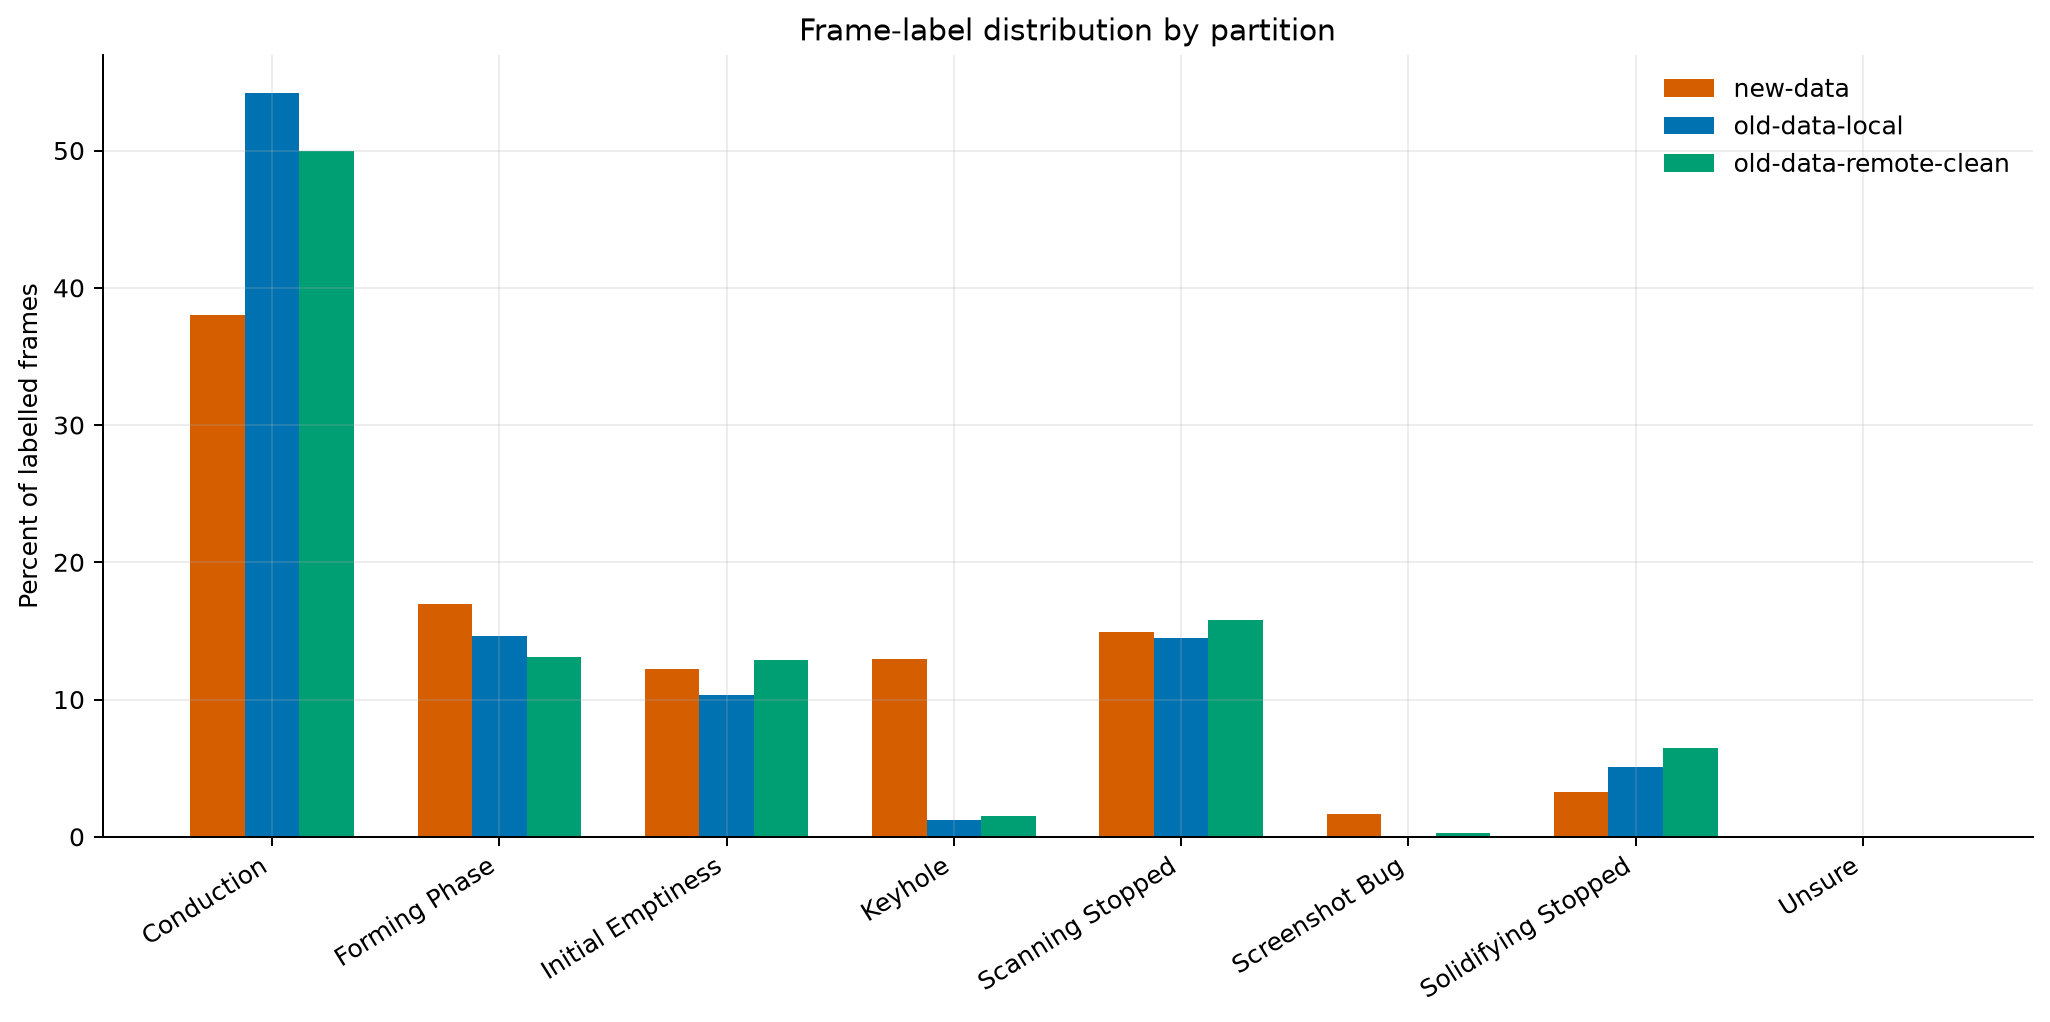

**02_experiment_label_prevalence_by_partition.png**

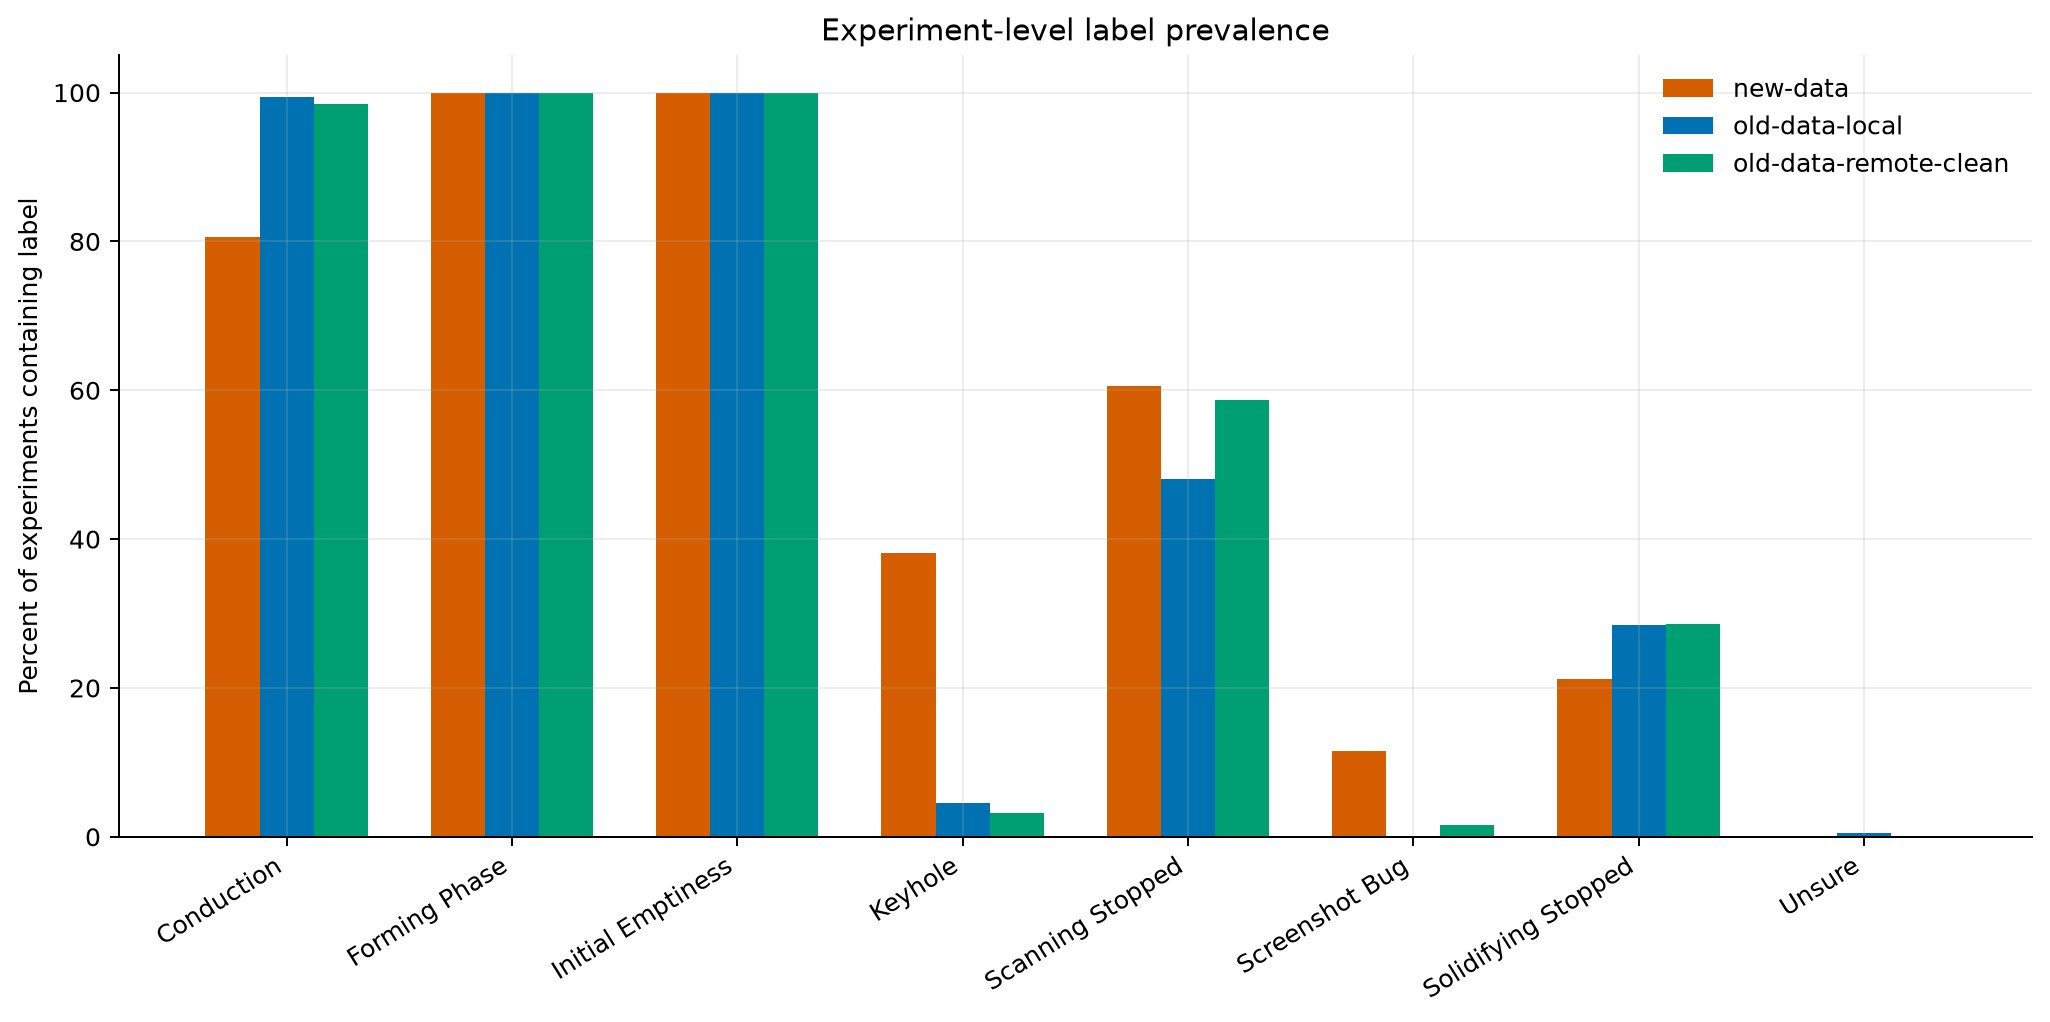

**03_keyhole_experiment_prevalence.png**

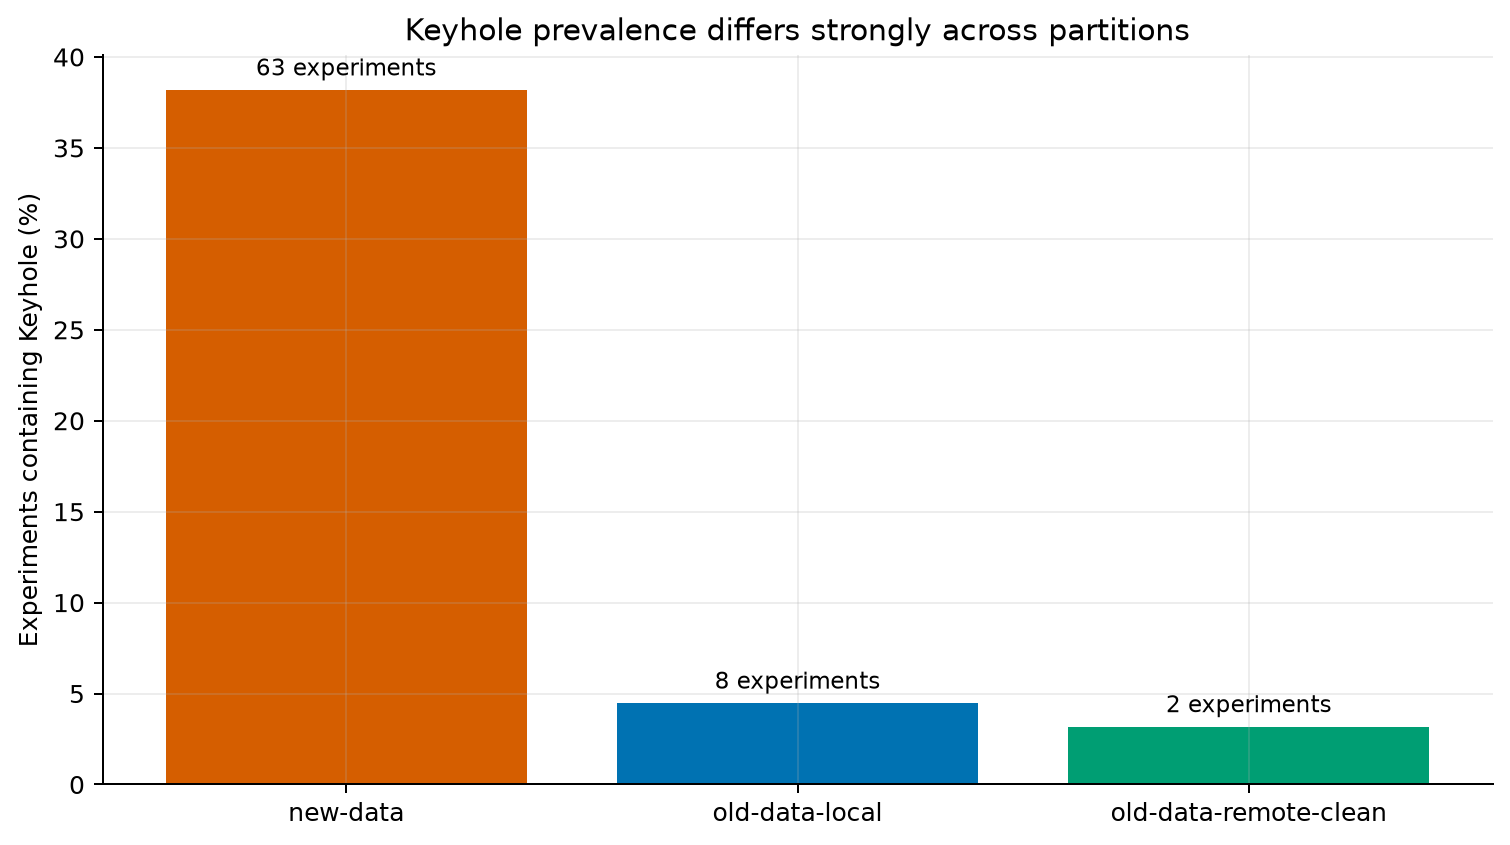

In [4]:
# These calls visibly repeat the core label and sequence calculations.
labels_now = load_partition_labels(workers=3)
distribution_now = label_distribution(labels_now)
sequences_now, episodes_now, patterns_now = sequence_audit(labels_now)

stored_distribution = pd.read_csv(OUT / "label_distribution.csv")
reference = pd.read_csv(OUT / "ioan_reference_comparison.csv")
assert len(labels_now) == provenance["labelled_frame_count"]
assert sequences_now["experiment_name"].nunique() == provenance["experiment_count"]

display(
    stored_distribution[stored_distribution["partition"].isin(PARTITION_ORDER)]
    [["partition", "label", "frame_count", "frame_percent", "experiment_count", "experiment_percent"]]
)
display(reference)
show_figures(
    "01_frame_label_distribution_by_partition.png",
    "02_experiment_label_prevalence_by_partition.png",
    "03_keyhole_experiment_prevalence.png",
)

**Interpretation.** All **20/20** reference checks pass: 407 experiments, 110,804 frames, 6,700 Keyhole frames in 73 experiments, and 52,080 Conduction frames in 373 experiments are reproduced exactly (percentages differ only by screenshot rounding). Experiment-level labels are **not mutually exclusive**: a simulation may contain Conduction and Keyhole at different saved timesteps, so their experiment prevalences need not sum to 100%.

## 5. Experiment-level sequences and Keyhole episodes

**What are we doing?** Collapse consecutive duplicate labels and calculate first/last physical labels, Keyhole locations, frame counts, fractions, and segment counts per experiment.  
**Why?** A binary experiment label hides whether Keyhole is brief, persistent, or repeatedly interrupted.  
**Question answered.** Which transition patterns occur, and how short are the shortest observed Keyhole episodes?  
**Suspicious result.** Impossible returns to initialization, many isolated segments, or an unjustified conversion from saved frames to milliseconds.

,partition,collapsed_label_sequence,experiment_count,partition_experiment_count,experiment_percent
0,combined,Initial Emptiness -> Forming Phase -> Conduction,135,407,33.169533
1,combined,Initial Emptiness -> Forming Phase -> Conduction -> Scanning Stopped,95,407,23.341523
2,combined,Initial Emptiness -> Forming Phase -> Conduction -> Scanning Stopped -> Solidifying St...,92,407,22.604423
3,combined,Initial Emptiness -> Forming Phase -> Keyhole,27,407,6.633907
4,combined,Initial Emptiness -> Forming Phase -> Conduction -> Keyhole,8,407,1.965602
5,combined,Initial Emptiness -> Forming Phase -> Keyhole -> Conduction,6,407,1.474201
6,combined,Initial Emptiness -> Forming Phase -> Keyhole -> Scanning Stopped -> Screenshot Bug,4,407,0.982801
7,combined,Forming Phase -> Initial Emptiness -> Forming Phase -> Conduction -> Scanning Stopped ...,2,407,0.491400
8,combined,Forming Phase -> Initial Emptiness -> Forming Phase -> Conduction -> Scanning Stopped,1,407,0.245700
9,combined,Forming Phase -> Initial Emptiness -> Forming Phase -> Keyhole -> Forming Phase -> Con...,1,407,0.245700


,partition,experiment_name,first_physical_label,last_physical_label,first_keyhole_timestep,last_keyhole_timestep,keyhole_frame_count,keyhole_segment_count,keyhole_transient_by_sequence,keyhole_persistent_to_last_physical_frame,collapsed_label_sequence
46,new-data,P-208p096600196_VX-0p256636148953_LS-4p52492384214e-05_ST-395p602757306_M-TI64_XI-0p00...,Forming Phase,Conduction,65174.0,78630.0,14,1,True,False,Initial Emptiness -> Forming Phase -> Keyhole -> Conduction
53,new-data,P-212p944274192_VX-0p351323873231_LS-4p80439392259e-05_ST-351p894554175_M-TI64_XI-0p00...,Forming Phase,Conduction,58941.0,63477.0,7,1,True,False,Initial Emptiness -> Forming Phase -> Keyhole -> Forming Phase -> Conduction
58,new-data,P-227p095146149_VX-0p485569900572_LS-4p61845747353e-05_ST-309p475761642_M-TI64_XI-0p00...,Forming Phase,Keyhole,38259.0,115599.0,143,1,False,True,Initial Emptiness -> Forming Phase -> Keyhole
69,new-data,P-243p042265843_VX-0p642372627708_LS-5p19118052277e-05_ST-314p809567363_M-TI64_XI-0p00...,Forming Phase,Conduction,33461.0,38009.0,4,2,True,False,Initial Emptiness -> Forming Phase -> Keyhole -> Conduction -> Keyhole -> Conduction -...
81,new-data,P-264p370573209_VX-0p395776293281_LS-4p78236029631e-05_ST-378p311267492_M-TI64_XI-0p00...,Forming Phase,Keyhole,43592.0,115599.0,109,1,False,True,Initial Emptiness -> Forming Phase -> Keyhole
85,new-data,P-270p660461155_VX-0p506275452772_LS-4p55363433165e-05_ST-392p157982605_M-TI64_XI-0p00...,Forming Phase,Keyhole,35644.0,115599.0,154,1,False,True,Initial Emptiness -> Forming Phase -> Keyhole
88,new-data,P-277p972333632_VX-0p331196372511_LS-4p5620211888e-05_ST-324p411035281_M-TI64_XI-0p000...,Forming Phase,Keyhole,49692.0,115599.0,84,1,False,True,Initial Emptiness -> Forming Phase -> Keyhole
90,new-data,P-282p804328276_VX-0p543976889672_LS-5p22197252327e-05_ST-303p777238342_M-TI64_XI-0p00...,Forming Phase,Keyhole,35124.0,115599.0,165,1,False,True,Initial Emptiness -> Forming Phase -> Keyhole
94,new-data,P-293p648784497_VX-0p426690912013_LS-5p33940457289e-05_ST-351p677261216_M-TI64_XI-0p00...,Forming Phase,Keyhole,44789.0,115599.0,114,1,False,True,Initial Emptiness -> Forming Phase -> Keyhole
103,new-data,P-326p931045044_VX-0p255856443683_LS-6p48737236991e-05_ST-399p817710522_M-TI64_XI-0p00...,Forming Phase,Conduction,67449.0,94443.0,27,1,True,False,Initial Emptiness -> Forming Phase -> Keyhole -> Conduction


,frame-based diagnostic,Keyhole-positive experiments
0,exactly 1,0
1,at most 3,2
2,at most 5,5
3,at most 20,14
4,more than one segment,16


**09_label_sequence_patterns.png**

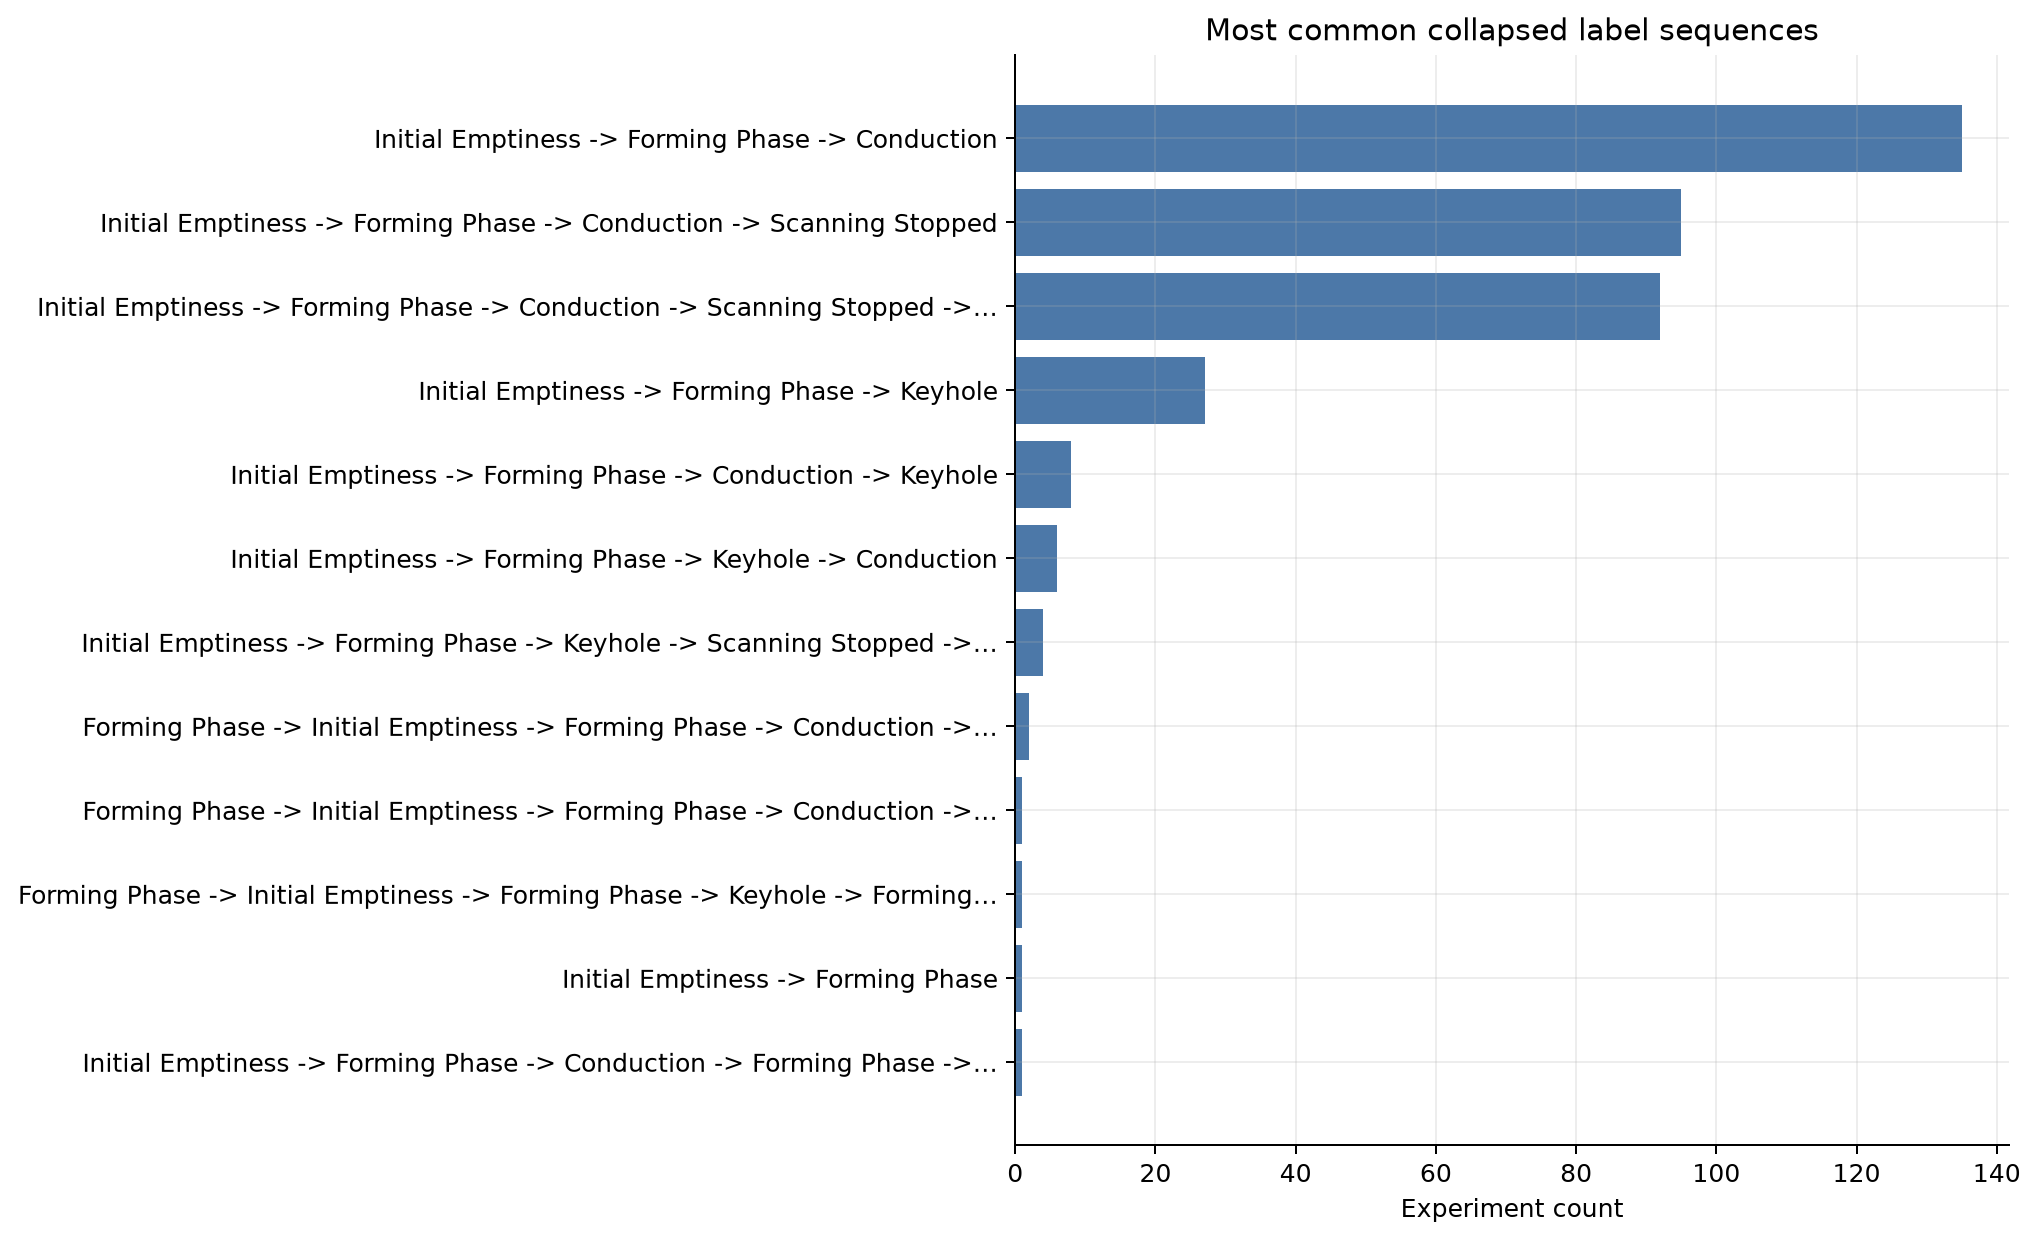

**10_keyhole_duration_segments.png**

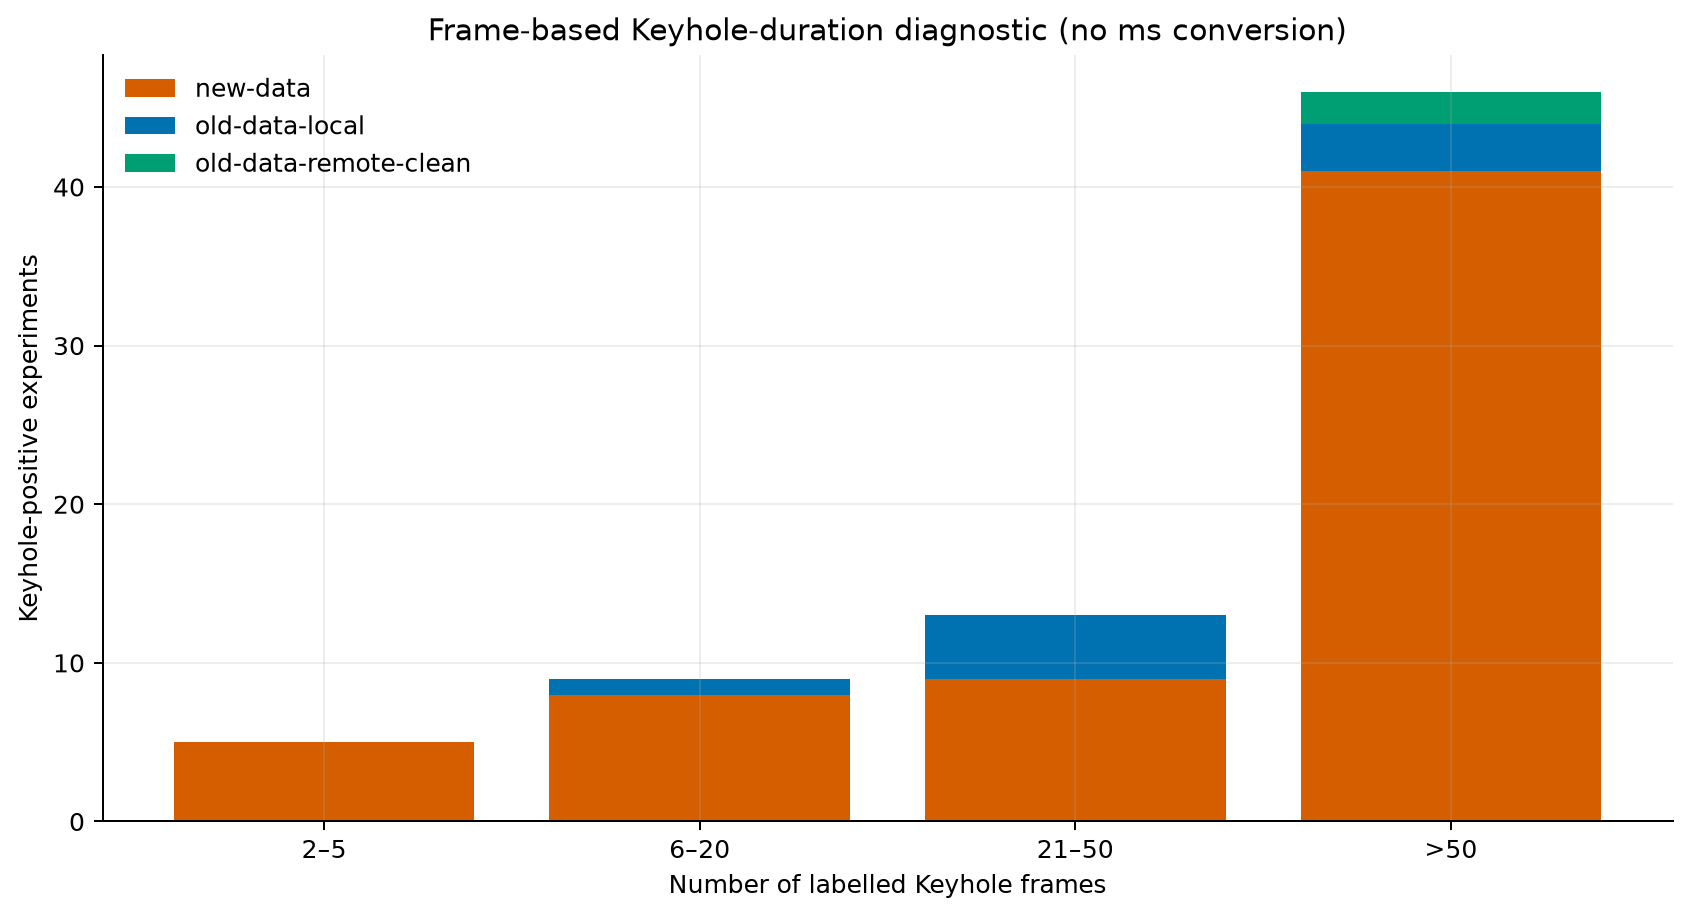

In [5]:
sequences = pd.read_csv(OUT / "experiment_label_sequences.csv")
patterns = pd.read_csv(OUT / "label_sequence_patterns.csv")
episodes = pd.read_csv(OUT / "keyhole_episodes.csv")
keyhole = sequences[sequences["has_keyhole"]].copy()

display(patterns[patterns["partition"].eq("combined")].head(15))
display(keyhole[[
    "partition", "experiment_name", "first_physical_label", "last_physical_label",
    "first_keyhole_timestep", "last_keyhole_timestep", "keyhole_frame_count",
    "keyhole_segment_count", "keyhole_transient_by_sequence",
    "keyhole_persistent_to_last_physical_frame", "collapsed_label_sequence",
]].head(12))
display(pd.DataFrame({
    "frame-based diagnostic": ["exactly 1", "at most 3", "at most 5", "at most 20", "more than one segment"],
    "Keyhole-positive experiments": [
        int((keyhole["keyhole_frame_count"] == 1).sum()),
        int((keyhole["keyhole_frame_count"] <= 3).sum()),
        int((keyhole["keyhole_frame_count"] <= 5).sum()),
        int((keyhole["keyhole_frame_count"] <= 20).sum()),
        int((keyhole["keyhole_segment_count"] > 1).sum()),
    ],
}))
show_figures("09_label_sequence_patterns.png", "10_keyhole_duration_segments.png")

**Interpretation.** No Keyhole-positive experiment has only one saved Keyhole frame; **2** have at most three and **5** have at most five. **16** contain repeated Keyhole segments. The repository provides exact solver timesteps for saved frames, but Phase 1 does not yet validate a general frame-duration-to-millisecond rule; therefore these duration statements remain frame-based.

## 6. Working-student provenance and suspicious-label flags

**What are we doing?** Search for reliable annotator metadata and flag sequence/channel patterns that warrant later review.  
**Why?** Ioan warned that a smaller subset was labelled by a working student, but partition names or label channels must not be treated as annotator identity without evidence.  
**Question answered.** Can that subset be identified, and which records deserve manual review?  
**Suspicious result.** Fabricating an annotator split, calling disagreements “wrong”, modifying labels, or dropping flagged records.

In [6]:
annotator = pd.read_csv(OUT / "annotator_provenance_audit.csv")
anomalies = pd.read_csv(OUT / "suspicious_label_anomalies.csv")
display(annotator)
display(
    anomalies.groupby(["severity", "reason"])
    .agg(records=("experiment_name", "size"), experiments=("experiment_name", "nunique"))
    .sort_values("records", ascending=False).reset_index()
)
display(anomalies[~anomalies["reason"].eq("annotator_or_channel_disagreement")].head(20))

,question,answer,status,evidence,label_columns,provenance_path_count,provenance_paths,decision
0,Can working-student-labelled records be identified reliably?,No,WARNING,No annotator/label-provenance column is present in the three ledgers; no annotator or ...,"[""label_1"", ""label_2"", ""label_final"", ""partition_label_file""]",0,[],Do not fabricate an annotator split; retain partition and disagreement diagnostics only.


,severity,reason,records,experiments
0,WARNING,annotator_or_channel_disagreement,387,387
1,WARNING,bug_free_flag_zero,20,20
2,WARNING,contains_screenshot_bug,20,20
3,WARNING,repeated_keyhole_episodes,16,16
4,WARNING,final_label_differs_from_both_inputs,13,13
5,WARNING,forming_phase_returns_after_conduction_or_keyhole,12,12
6,WARNING,initial_emptiness_after_physical_onset,8,8
7,WARNING,contains_unsure,1,1


,severity,reason,partition,experiment_name,affected_label_frame_indices,affected_timesteps,detail,gif_path_in_repository,label_was_modified,manual_review_recommended
18,WARNING,final_label_differs_from_both_inputs,new-data,P-140p236446589_VX-0p550532928497_LS-7p91865165046e-05_ST-370p758962256_M-TI64_XI-0p00...,[77],[38566],1 final labels differ from both label_1 and label_2,P-140p236446589_VX-0p550532928497_LS-7p91865165046e-05_ST-370p758962256_M-TI64_XI-0p00...,False,True
19,WARNING,initial_emptiness_after_physical_onset,new-data,P-140p236446589_VX-0p550532928497_LS-7p91865165046e-05_ST-370p758962256_M-TI64_XI-0p00...,[77],[38566],1 frames,P-140p236446589_VX-0p550532928497_LS-7p91865165046e-05_ST-370p758962256_M-TI64_XI-0p00...,False,True
30,WARNING,final_label_differs_from_both_inputs,new-data,P-163p562272254_VX-0p729793018519_LS-5p10150522361e-05_ST-318p261957537_M-TI64_XI-0p00...,[77],[28356],1 final labels differ from both label_1 and label_2,P-163p562272254_VX-0p729793018519_LS-5p10150522361e-05_ST-318p261957537_M-TI64_XI-0p00...,False,True
54,WARNING,final_label_differs_from_both_inputs,new-data,P-210p331349445_VX-0p877062157481_LS-5p88084341536e-05_ST-346p930868597_M-TI64_XI-0p00...,[246],[74774],1 final labels differ from both label_1 and label_2,P-210p331349445_VX-0p877062157481_LS-5p88084341536e-05_ST-346p930868597_M-TI64_XI-0p00...,False,True
58,WARNING,forming_phase_returns_after_conduction_or_keyhole,new-data,P-212p944274192_VX-0p351323873231_LS-4p80439392259e-05_ST-351p894554175_M-TI64_XI-0p00...,"[85,86,87,88,89,90,91,92,93,94,95]","[64234,64990,65746,66502,67258,68014,68770,69526,70282,71038,71795]",11 frames,P-212p944274192_VX-0p351323873231_LS-4p80439392259e-05_ST-351p894554175_M-TI64_XI-0p00...,False,True
71,WARNING,final_label_differs_from_both_inputs,new-data,P-238p364831187_VX-0p683428278389_LS-5p30391716287e-05_ST-377p396343519_M-TI64_XI-0p00...,[0],[0],1 final labels differ from both label_1 and label_2,P-238p364831187_VX-0p683428278389_LS-5p30391716287e-05_ST-377p396343519_M-TI64_XI-0p00...,False,True
72,WARNING,initial_emptiness_after_physical_onset,new-data,P-238p364831187_VX-0p683428278389_LS-5p30391716287e-05_ST-377p396343519_M-TI64_XI-0p00...,"[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,3...","[389,777,1165,1553,1942,2330,2718,3106,3494,3883,4271,4659,5047,5436,5824,6212,6988,73...",33 frames,P-238p364831187_VX-0p683428278389_LS-5p30391716287e-05_ST-377p396343519_M-TI64_XI-0p00...,False,True
77,WARNING,repeated_keyhole_episodes,new-data,P-243p042265843_VX-0p642372627708_LS-5p19118052277e-05_ST-314p809567363_M-TI64_XI-0p00...,[],[],2 distinct segments,P-243p042265843_VX-0p642372627708_LS-5p19118052277e-05_ST-314p809567363_M-TI64_XI-0p00...,False,True
79,WARNING,final_label_differs_from_both_inputs,new-data,P-250p363893775_VX-0p962117015407_LS-8p16921850603e-05_ST-395p976068127_M-TI64_XI-0p00...,[0],[0],1 final labels differ from both label_1 and label_2,P-250p363893775_VX-0p962117015407_LS-8p16921850603e-05_ST-395p976068127_M-TI64_XI-0p00...,False,True
80,WARNING,initial_emptiness_after_physical_onset,new-data,P-250p363893775_VX-0p962117015407_LS-8p16921850603e-05_ST-395p976068127_M-TI64_XI-0p00...,"[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30]","[276,552,828,1104,1655,1931,2207,2482,2758,3034,3310,3585,3861,4137,4413,4688,4964,551...",30 frames,P-250p363893775_VX-0p962117015407_LS-8p16921850603e-05_ST-395p976068127_M-TI64_XI-0p00...,False,True


**Interpretation.** The working-student subset is **not reliably identifiable**: no annotator/provenance field or file documents who `label_1` and `label_2` represent, and partition is not used as a proxy. Channel disagreement appears in **387/407 experiments**; it is retained as a broad review flag, not evidence that either channel is wrong. Smaller, more specific flags include Screenshot Bug, repeated Keyhole episodes, and unusual returns to earlier phases. No label is changed.

## 7. Parameter-space and Week 6 domain-shift audit

**What are we doing?** Verify units and compare P, VX, LS, and ST distributions, marginal bounds, axis-range membership, and four-dimensional convex-hull membership.  
**Why?** Models fitted later could be affected by design-space/covariate shift, but this phase must remain descriptive.  
**Question answered.** Which input regions are genuinely new, and where are Keyhole observations located?  
**Suspicious result.** Causal wording, unit mismatch, non-finite values, or interpreting a 2-D projection as full 4-D support.

,source,partition,feature,unit,count,missing_count,min,q05,q25,median,mean,q75,q95,max,std,unique_count
0,sph_v2,new-data,P,W,165,0,102.928147,120.245188,203.030488,265.432978,277.334731,370.938359,437.579383,449.762376,101.338287,165
1,sph_v2,new-data,VX,m/s,165,0,0.203591,0.257058,0.448547,0.639693,0.631800,0.831534,0.961924,0.993777,0.223016,165
2,sph_v2,new-data,LS,m,165,0,0.000040,0.000041,0.000044,0.000057,0.000060,0.000073,0.000086,0.000089,0.000015,165
3,sph_v2,new-data,ST,K,165,0,300.218383,303.782677,324.134517,347.682709,349.538950,375.783913,395.592093,399.817711,30.304748,165
4,sph_v2,old-data-local,P,W,179,0,52.544586,74.352324,112.666560,151.505872,156.337083,203.221178,238.344240,248.695097,53.617106,179
5,sph_v2,old-data-local,VX,m/s,179,0,0.201002,0.232652,0.424874,0.635787,0.621988,0.844862,0.958757,0.995510,0.238561,168
6,sph_v2,old-data-local,LS,m,179,0,0.000045,0.000045,0.000051,0.000062,0.000063,0.000075,0.000085,0.000088,0.000014,153
7,sph_v2,old-data-local,ST,K,179,0,300.000000,300.000000,312.972997,347.110895,344.381675,371.838208,394.864424,399.182507,32.540428,153
8,sph_v2,old-data-remote-clean,P,W,63,0,76.698613,91.570050,124.087023,162.201107,164.751989,212.168555,239.907607,246.882256,52.085215,63
9,sph_v2,old-data-remote-clean,VX,m/s,63,0,0.225166,0.253224,0.375991,0.584147,0.599713,0.824003,0.965980,0.998321,0.247780,63


,feature,unit,week6_min,week6_max,sph_v2_new_data_min,sph_v2_new_data_max,minimum_shift,maximum_shift,range_expansion_below_week6,range_expansion_above_week6,overlap_min,overlap_max,overlap_width,week6_range_width,new_range_width
0,P,W,52.544586,248.695097,102.928147,449.762376,50.383560,2.010673e+02,0.000000,201.067279,102.928147,248.695097,145.766951,196.150511,346.834229
1,VX,m/s,0.201002,0.998321,0.203591,0.993777,0.002588,-4.544266e-03,0.000000,0.000000,0.203591,0.993777,0.790186,0.797319,0.790186
2,LS,m,0.000045,0.000090,0.000040,0.000089,-0.000005,-9.387656e-07,0.000005,0.000000,0.000045,0.000089,0.000044,0.000045,0.000049
3,ST,K,300.000000,399.457924,300.218383,399.817711,0.218383,3.597865e-01,0.000000,0.359787,300.218383,399.457924,99.239541,99.457924,99.599327


,new-data region,experiments,Keyhole-positive
0,inside all Week 6 marginal ranges,70,4
1,outside at least one Week 6 marginal range,95,59
2,inside Week 6 4-D convex hull,47,1
3,outside Week 6 4-D convex hull,118,62


**04_parameter_distributions_by_partition.png**

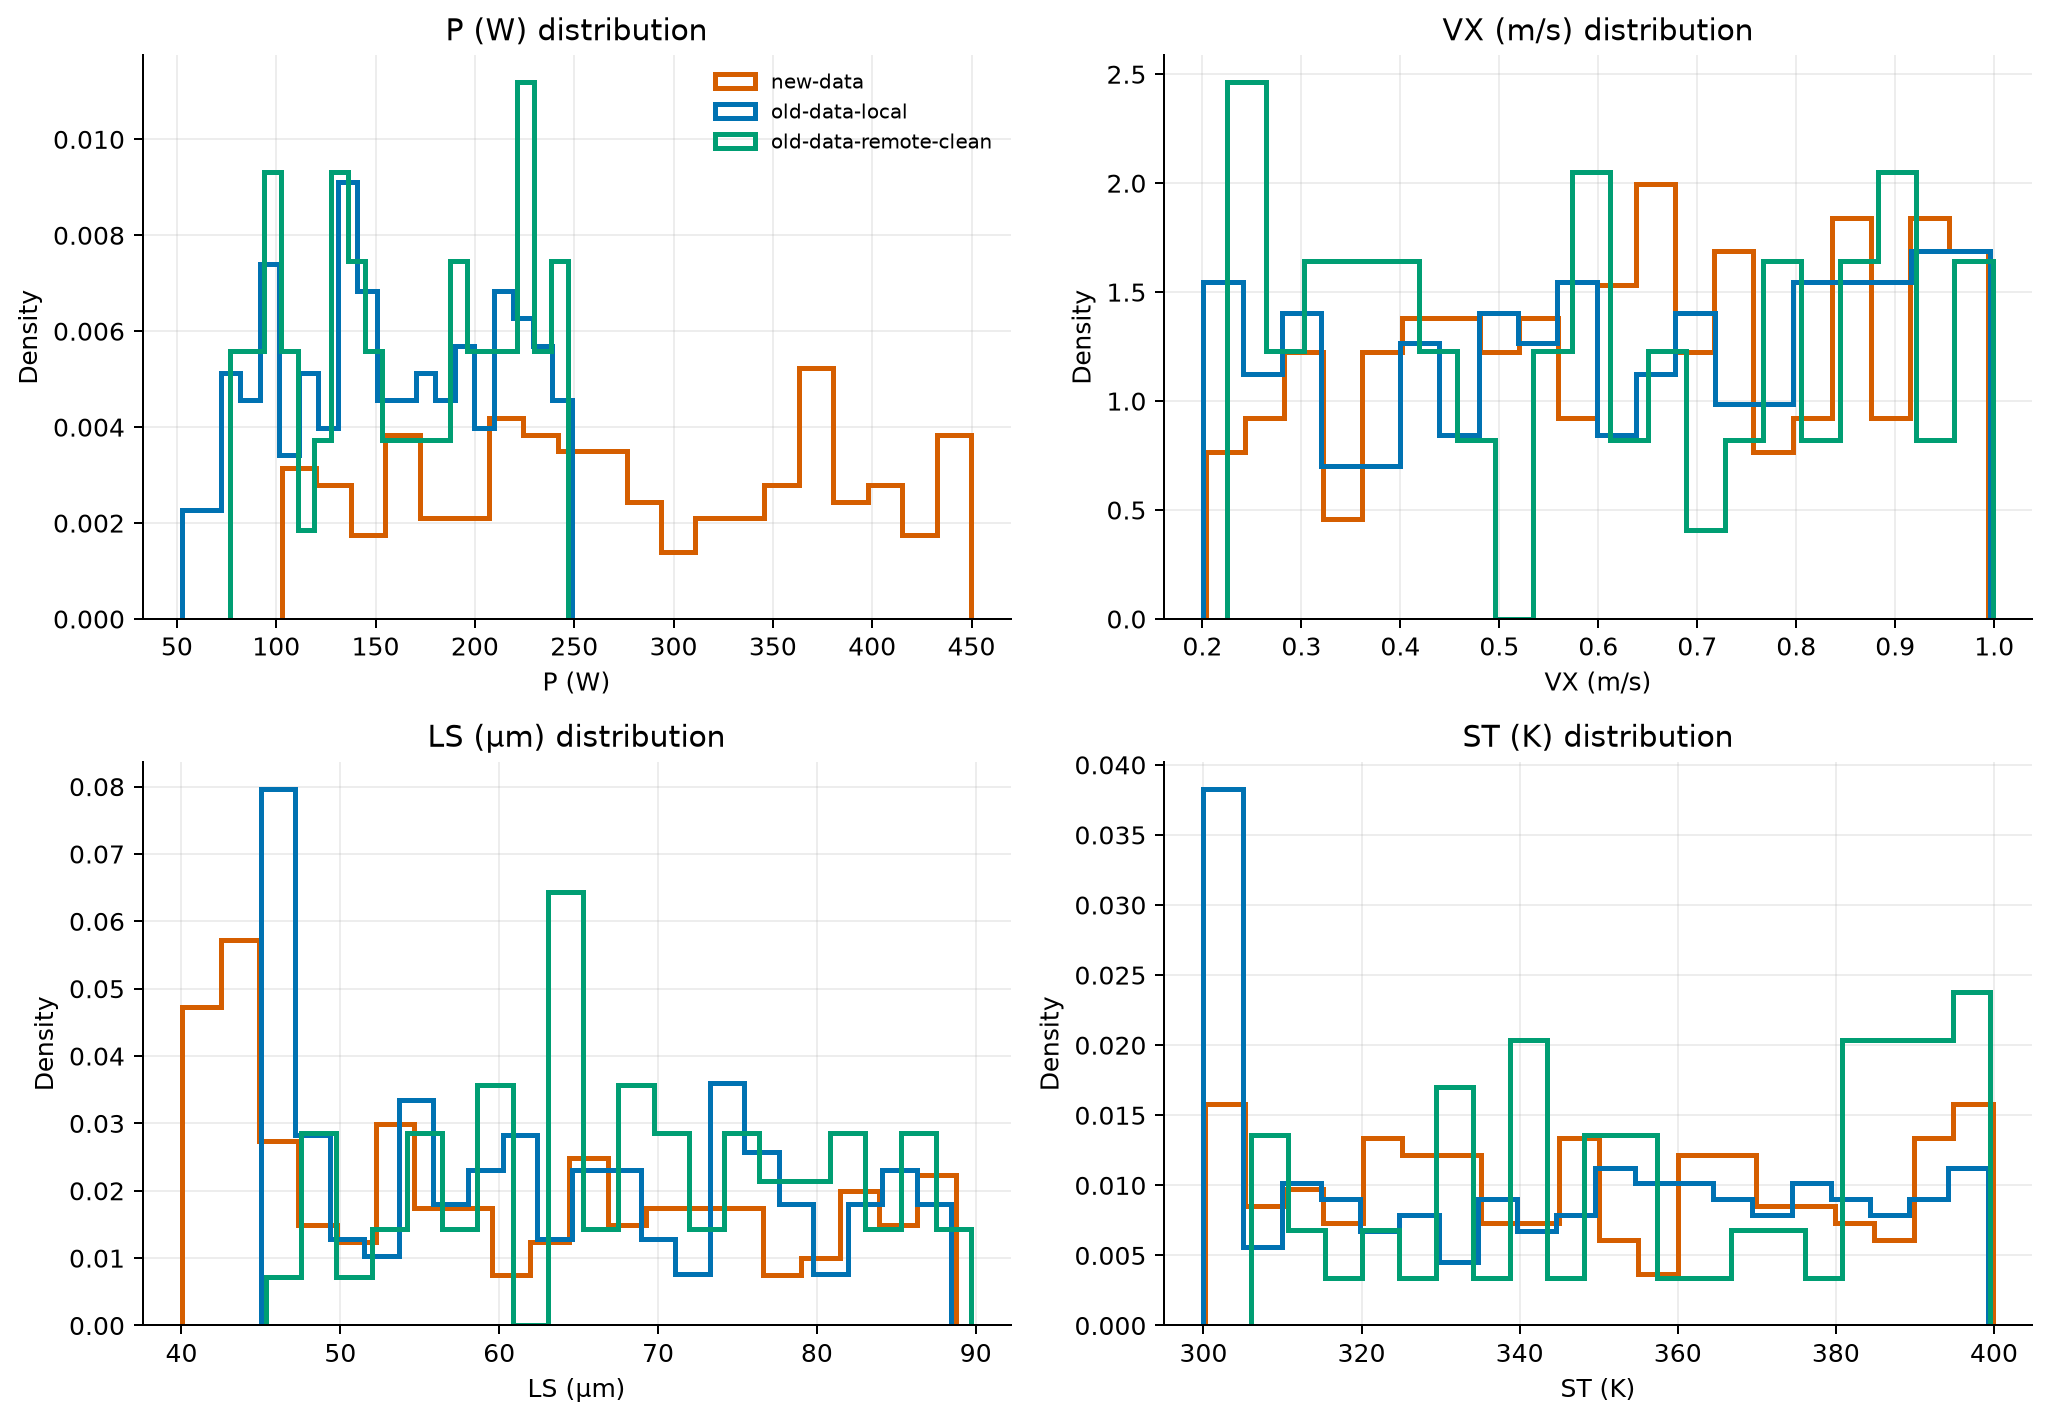

**05_parameter_boxplots_by_partition.png**

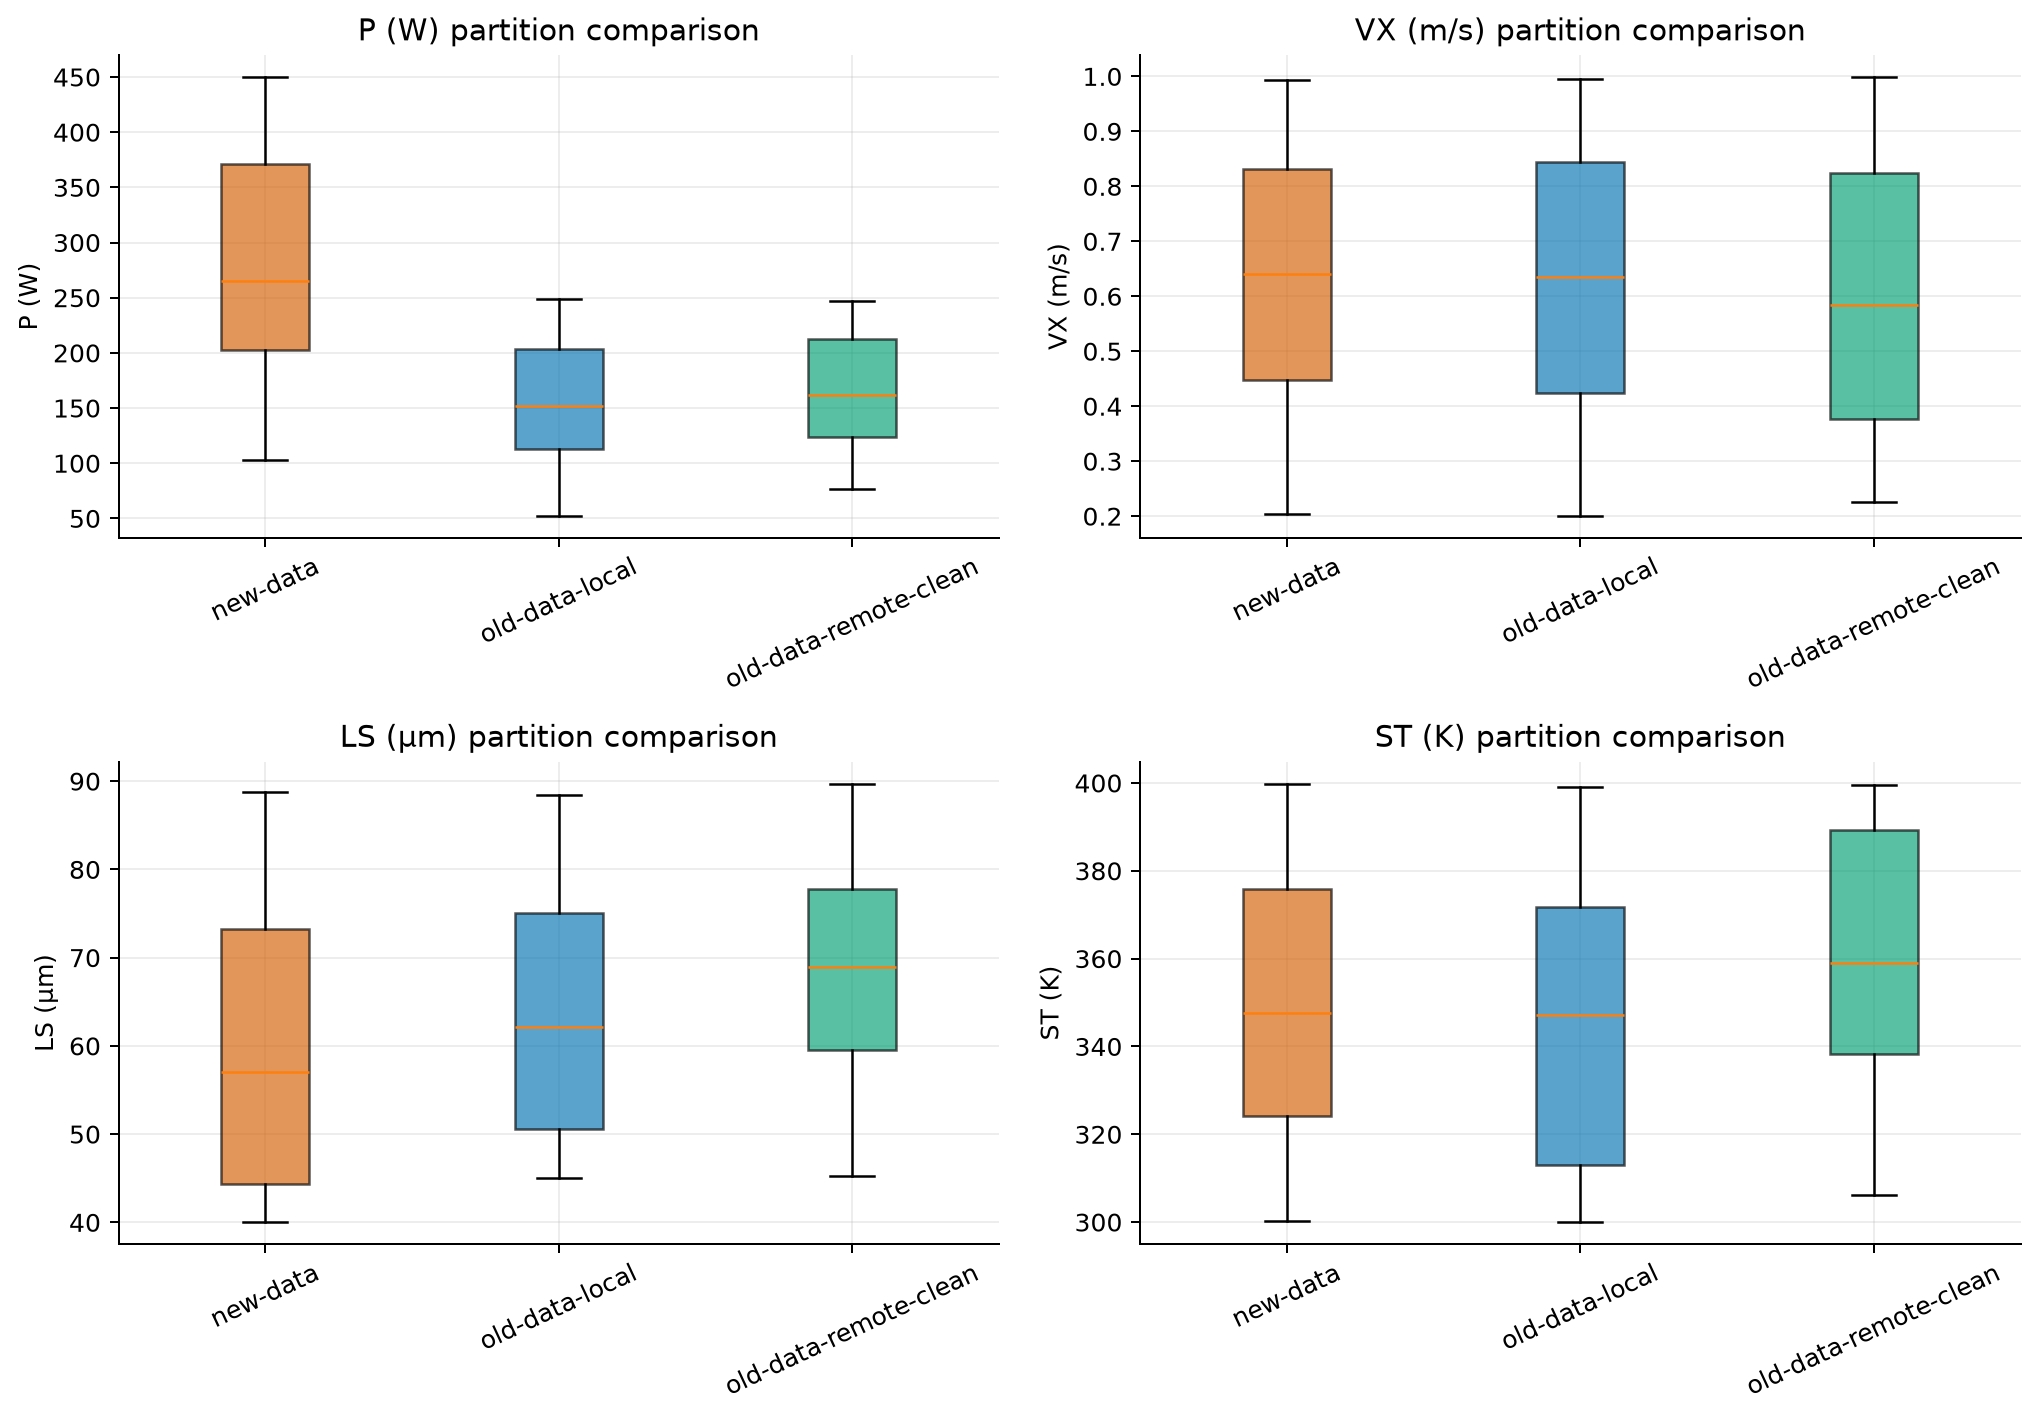

**06_parameter_space_projections.png**

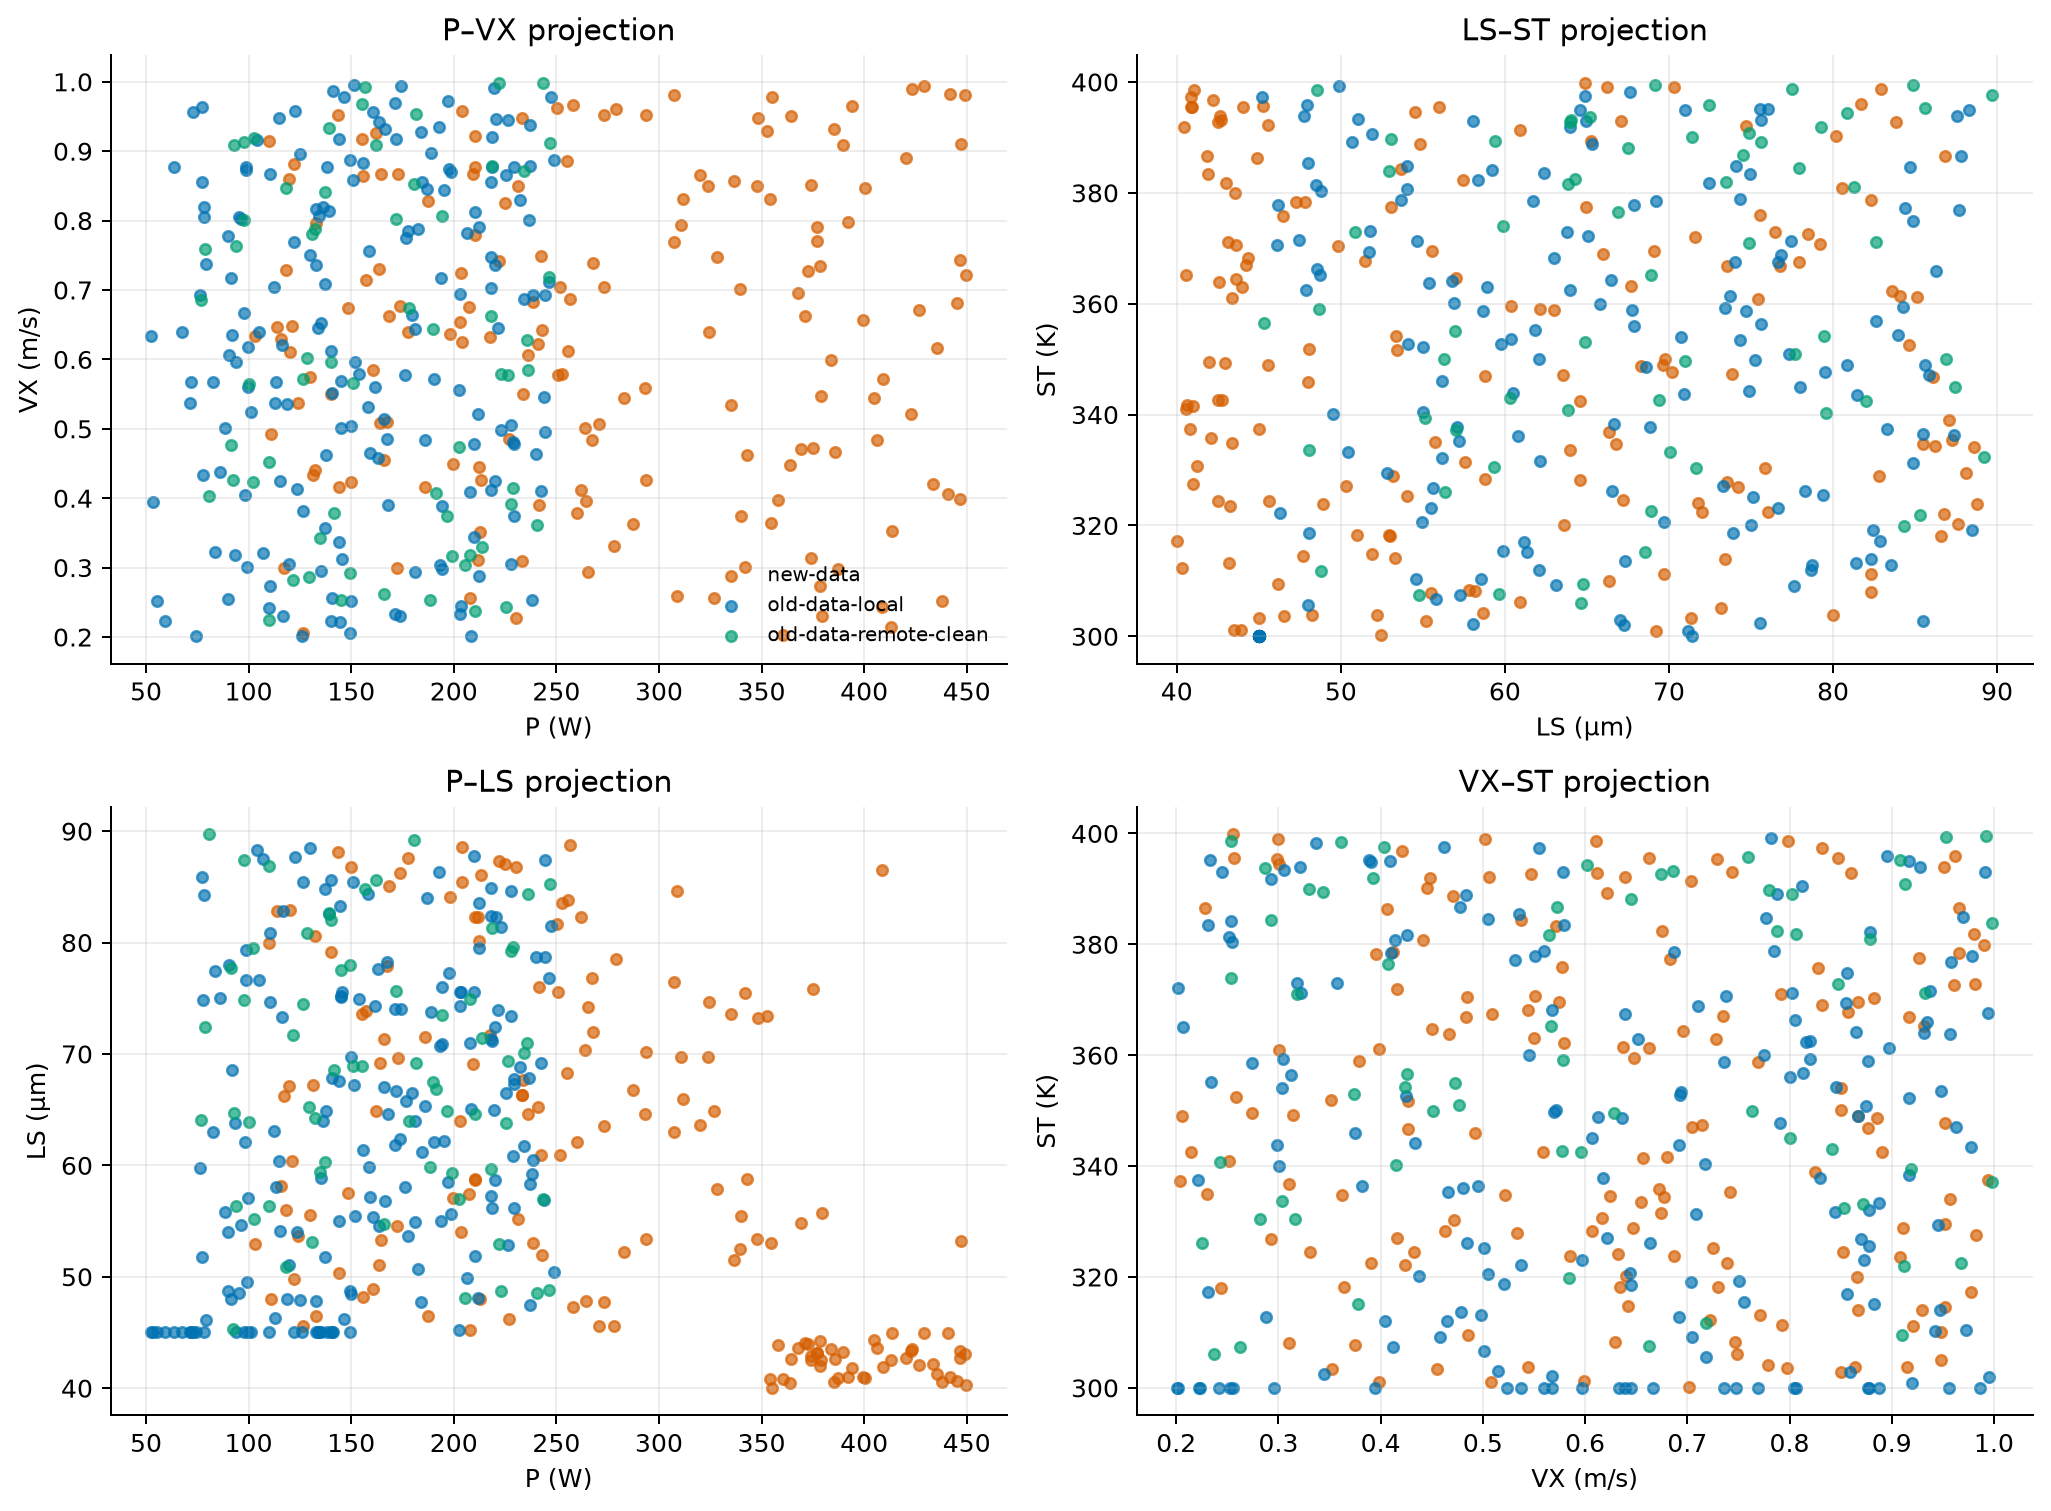

**07_week6_vs_new_parameter_bounds.png**

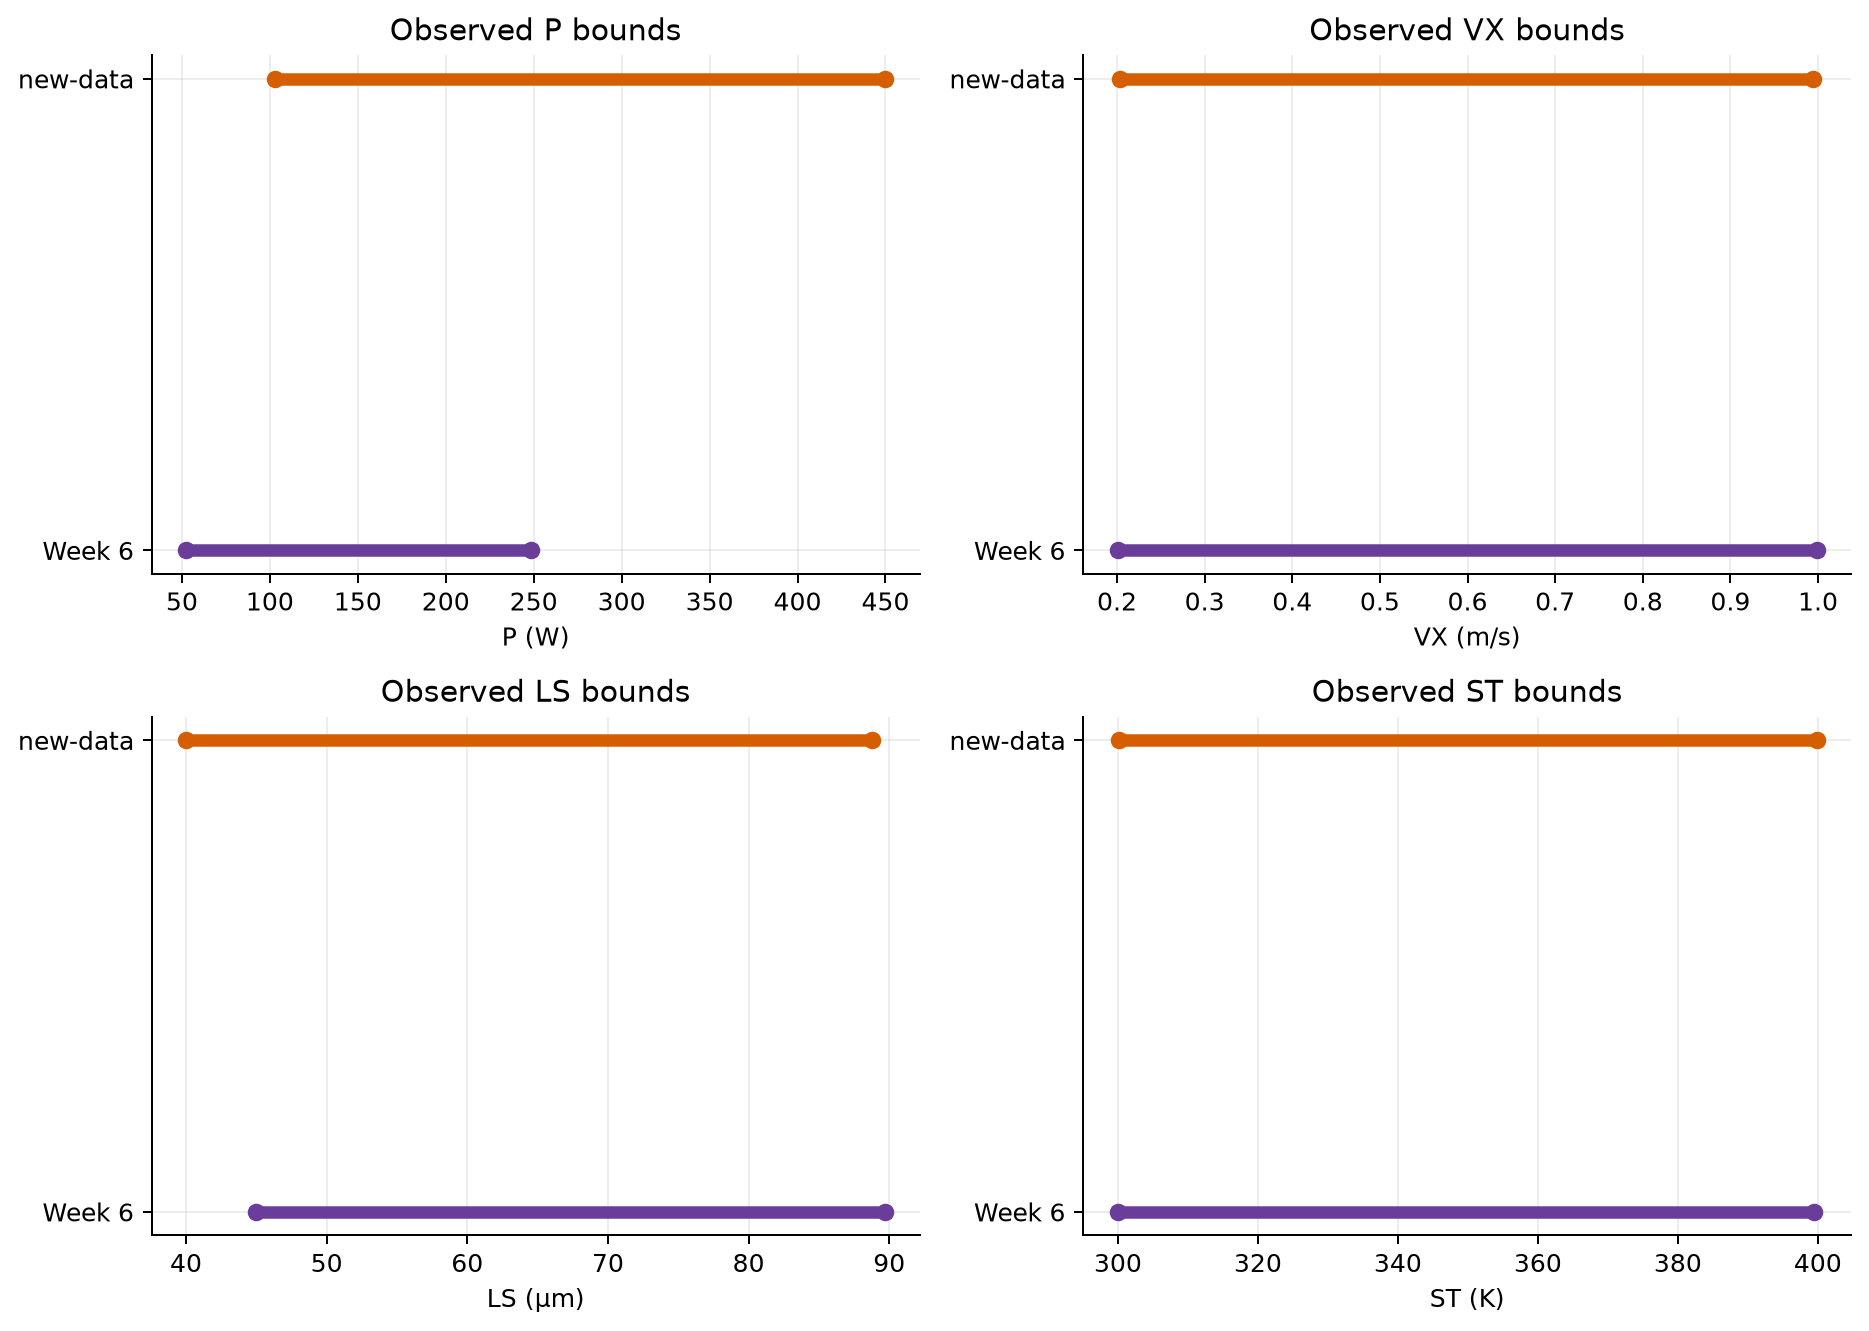

**08_keyhole_parameter_overlays.png**

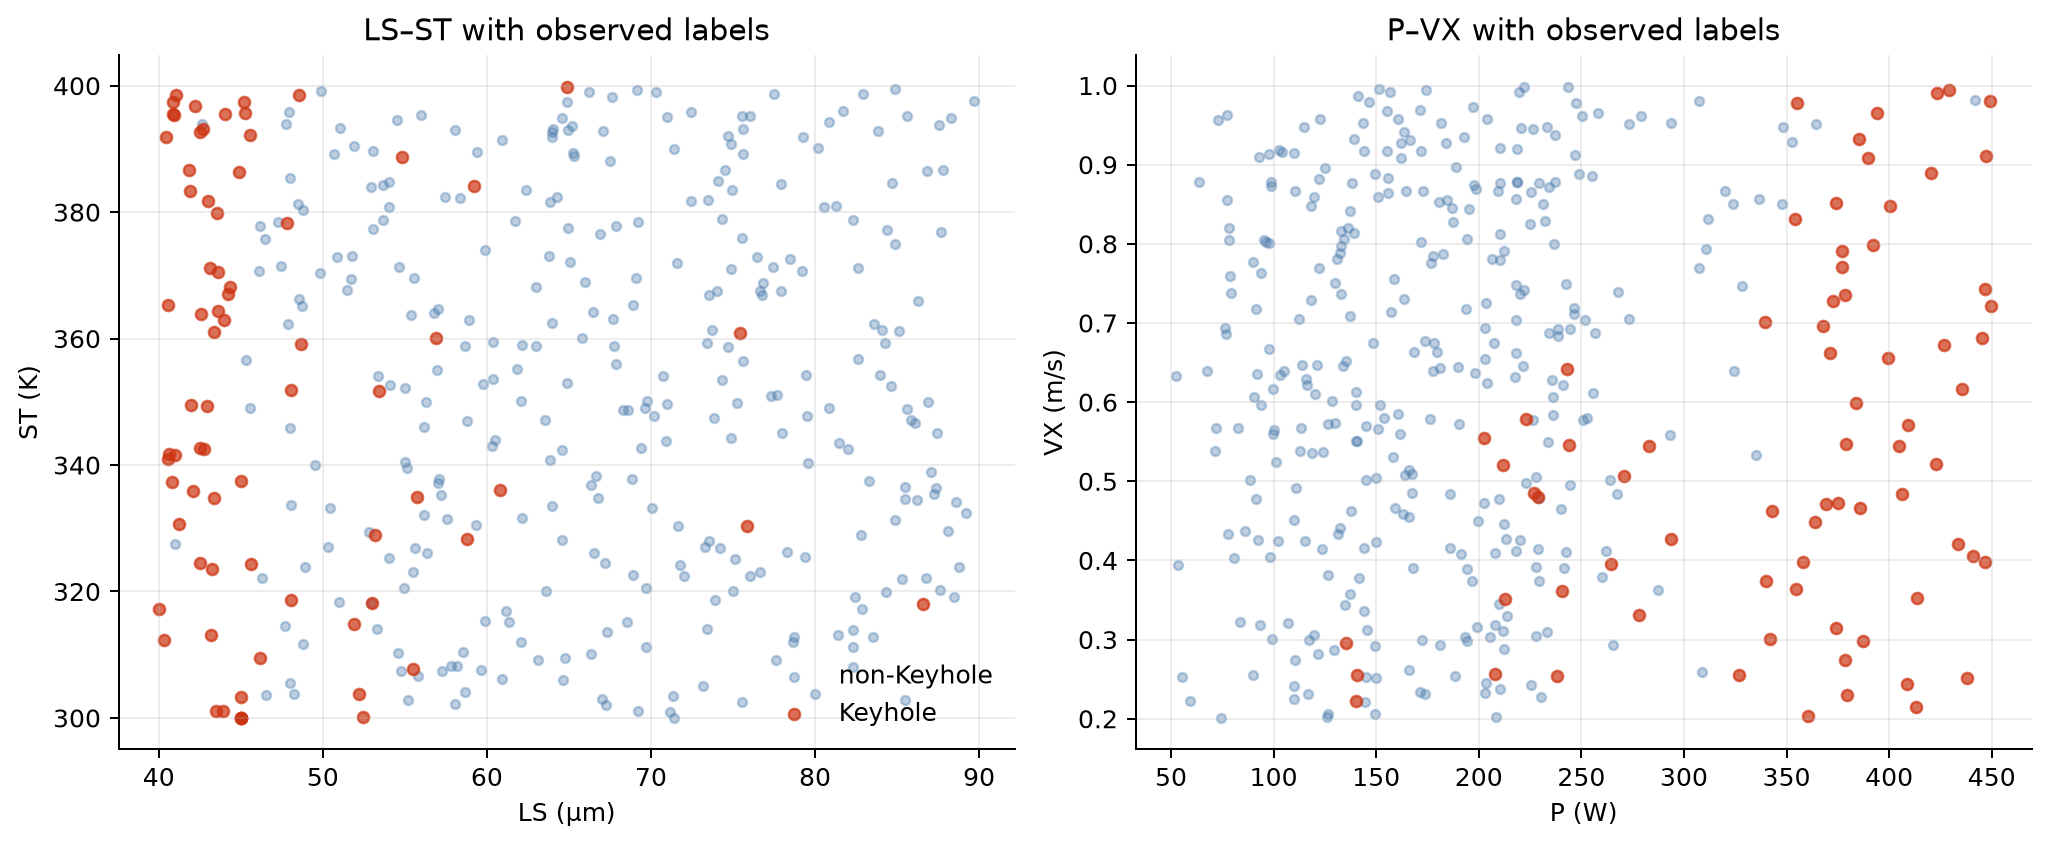

In [7]:
parameter_summary = pd.read_csv(OUT / "parameter_summary_by_partition.csv")
bounds = pd.read_csv(OUT / "parameter_bounds_shift.csv")
membership = pd.read_csv(OUT / "new_data_domain_membership.csv")

display(parameter_summary)
display(bounds)
display(pd.DataFrame({
    "new-data region": ["inside all Week 6 marginal ranges", "outside at least one Week 6 marginal range", "inside Week 6 4-D convex hull", "outside Week 6 4-D convex hull"],
    "experiments": [
        int((~membership["outside_any_week6_axis_range"]).sum()),
        int(membership["outside_any_week6_axis_range"].sum()),
        int(membership["inside_week6_4d_convex_hull"].sum()),
        int((~membership["inside_week6_4d_convex_hull"]).sum()),
    ],
    "Keyhole-positive": [
        int(membership.loc[~membership["outside_any_week6_axis_range"], "has_keyhole"].sum()),
        int(membership.loc[membership["outside_any_week6_axis_range"], "has_keyhole"].sum()),
        int(membership.loc[membership["inside_week6_4d_convex_hull"], "has_keyhole"].sum()),
        int(membership.loc[~membership["inside_week6_4d_convex_hull"], "has_keyhole"].sum()),
    ],
}))
show_figures(
    "04_parameter_distributions_by_partition.png",
    "05_parameter_boxplots_by_partition.png",
    "06_parameter_space_projections.png",
    "07_week6_vs_new_parameter_bounds.png",
    "08_keyhole_parameter_overlays.png",
)

**Interpretation.** Units remain P in W, VX in m/s, LS in m (shown as µm in figures), and ST in K. Relative to Week 6, the `new-data` LS lower bound extends by **4.971 µm**, P extends upward by **201.067 W**, and ST extends upward by only **0.360 K**; VX adds no marginal range. **95/165** new experiments lie outside at least one Week 6 marginal range and **118/165** lie outside the Week 6 4-D convex hull. Keyhole prevalence is 62.1% outside at least one old marginal range versus 5.7% inside all four. This is a strong observed association with the newly sampled region, not evidence that smaller LS or higher P causes Keyhole.

## 8. Partition, identifier, and duplicate integrity

**What are we doing?** Distinguish duplicate identifiers/content from repeated parameter settings and compare complete folder-content bundles.  
**Why?** Equal P/VX/LS/ST can be a legitimate replicate; only identifier/content equivalence supports a duplicate claim.  
**Question answered.** Are experiments repeated across partitions, labels conflicting for the same identifier, or complete folders duplicated?  
**Suspicious result.** Treating any equal parameter tuple as the same simulation or silently deduplicating scientific rows.

In [8]:
integrity = pd.read_csv(OUT / "integrity_audit.csv")
bundles = pd.read_csv(OUT / "experiment_content_bundles.csv")
display(integrity if len(integrity) else pd.DataFrame({"integrity finding": ["No duplicate identifier, complete-content, cross-partition, tuple-conflict, or missing-input issue detected"]}))
display(bundles.groupby("partition").agg(
    experiments=("experiment_name", "nunique"),
    unique_content_bundles=("complete_content_bundle_sha256", "nunique"),
    repository_files=("file_count", "sum"),
).reset_index())

,integrity finding
0,"No duplicate identifier, complete-content, cross-partition, tuple-conflict, or missing..."


,partition,experiments,unique_content_bundles,repository_files
0,new-data,165,165,141892
1,old-data-local,179,179,153087
2,old-data-remote-clean,63,63,51489


**Interpretation.** The integrity audit found **0 reportable duplicate/conflict issues**. All 407 semantic identifiers and complete content-bundle hashes are unique, and no identifier crosses partitions. Nothing is removed. The audit logic keeps the important distinction between a replicated design point and duplicate simulation content.

## 9. Phase 1 conclusions

**What are we doing?** Separate observations, interpretations, and decisions before Phase 2.  
**Why?** A data audit should constrain later work without turning descriptive patterns into causal claims or silently correcting source data.  
**Question answered.** Is the pinned snapshot usable, and what must remain visible during target extraction?  
**Suspicious result.** Declaring the whole dataset clean despite monitor absences, or claiming the working-student labels are identifiable/wrong.

In [9]:
display(Markdown((OUT / "results_summary.md").read_text(encoding="utf-8")))
display(pd.DataFrame({"summary field": list(summary), "value": [summary[key] for key in summary]}))

# Week 7 Phase 1 — sph_v2 dataset and design-space audit

## Scope and provenance

This full audit used `ioandanielc/sph_v2@d69dac5bda8b622bc0de316b112815c6056c06ec`.  All
scientific access was pinned to that immutable revision; the floating `main`
pointer was recorded only as provenance.  No source label was changed, no
experiment was removed, and no predictive model was fitted.

## Reproduced population

- Experiments: **407**.
- Labelled frames: **110,804**.
- Experiments containing Keyhole: **73**.
- Experiments containing Conduction: **373**.
- Ioan reference checks: **20/20 PASS**.

At experiment level labels are not mutually exclusive: one simulation can pass
through both Conduction and Keyhole at different labelled timesteps.  Keyhole
duration is therefore reported in labelled frames and segments.  No conversion
to milliseconds is made because a repository-wide physical mapping from saved
frame index to time has not yet been validated.

## Label quality and annotator boundary

The working-student subset is **not reliably identifiable** from the pinned
repository.  There is no annotator/provenance field or file and the identities
behind `label_1` and `label_2` are undocumented.  A partition is not treated as
an annotator proxy.  The automated anomaly table contains **387**
experiments warranting review; these records remain in the data.

## Observed parameter-domain change

- LS lower-bound expansion relative to Week 6: **4.971 µm**.
- ST upper-bound expansion relative to Week 6: **0.360 K**.
- New-data experiments outside at least one Week 6 marginal range: **95/165**.
- New-data experiments outside the Week 6 four-dimensional convex hull: **118/165**.

These are observed design-space/covariate shifts.  They do not establish that
smaller LS or larger ST causes Keyhole.

## Phase 1 decision

The pinned repository is usable for the complete label/parameter audit and is
**partially usable** for Phase 2 physical extraction.  There are
**114 missing required-monitor entries across
57 experiments**.  Label anomalies, the absent annotator
split, and these structural gaps must remain visible.  Phase 2 must preserve
exact partition and revision provenance, retain every extraction failure as an
explicit row, and make no label corrections.

## Validation dashboard

- PASS: **21**
- WARNING: **0**
- FAIL: **1**


,summary field,value
0,anomaly_experiment_count,387
1,anomaly_record_count,477
2,conduction_experiment_count,373
3,conduction_frame_count,52080
4,experiment_count,407
5,ioan_reference_pass_count,20
6,ioan_reference_total,20
7,keyhole_experiment_count,73
8,keyhole_frame_count,6700
9,labelled_frame_count,110804


**Interpretation.** `sph_v2` is usable for a fail-closed Phase 2 migration, not uniformly complete: all **407 experiments** remain in scope, while the **57 monitor-incomplete experiments** must produce explicit failure rows. Ioan's population statistics are reproduced. The input domain expanded mainly toward higher P and smaller LS; the observed Keyhole coverage is concentrated in newly sampled input space. Annotator identity and visual validity of flagged label transitions remain unresolved.

## 10. Did we satisfy Week 7 Phase 1?

**What are we doing?** Display every validation and requested-item mapping.  
**Why?** A final dashboard makes scientific defects distinct from missing deliverables.  
**Question answered.** Which checks pass, which source-data caveats remain, and where is the evidence?  
**Suspicious result.** A blanket PASS that hides missing monitors or a notebook containing stored execution errors.

In [10]:
validation = pd.read_csv(OUT / "validation_results.csv")
checklist = pd.read_csv(OUT / "phase1_requirement_checklist.csv")
display(validation)
display(validation.groupby("status").size().rename("count").reset_index())
display(checklist)
assert summary["scope"]["predictive_models_fitted"] is False
assert summary["scope"]["active_learning"] is False
assert summary["scope"]["level_set_estimation"] is False

,validation_id,requirement,status,detail
0,V01,Exact sph_v2 revision recorded,PASS,d69dac5bda8b622bc0de316b112815c6056c06ec
1,V02,Scientific downloads use no floating revision,PASS,All hf_hub_download and tree calls use the 40-character revision
2,V03,Experiment count internally consistent,PASS,registry=407; sequence=407; expected=407
3,V04,Frame count internally consistent,PASS,labels=110804; registry sum=110804
4,V05,Partition totals sum correctly,PASS,"{'new-data': 45156, 'old-data-local': 49304, 'old-data-remote-clean': 16344}"
5,V06,Label totals sum correctly,PASS,label total=110804
6,V07,All P/VX/LS/ST finite,PASS,four parameters checked in every registry row
7,V08,Experiment identifiers unique,PASS,unique=407; rows=407
8,V09,Folder/JSON/partition inputs agree,PASS,mismatches=0
9,V10,Input units agree with Week 6,PASS,"{'P': 'W', 'VX': 'm/s', 'LS': 'm', 'ST': 'K'}"


,status,count
0,FAIL,1
1,PASS,21


,requirement_id,requirement,status,notebook_section,output_artifact,validation_ids
0,P1-01,"Exact Hugging Face revision resolved, pinned, and displayed",PASS,Notebook §2,dataset_provenance.json; dataset_provenance_table.csv,V01;V02
1,P1-02,Complete repository tree and file types audited,PASS,Notebook §3,repository_file_inventory.parquet; file_type_counts.csv,V01;V03;V04
2,P1-03,Partition and missing-file structure audited,WARNING,Notebook §3,partition_summary.csv; missing_unexpected_files.csv,V13;V14
3,P1-04,New structure compared with Week 6,PASS,Notebook §3,week6_structure_comparison.csv,V09;V10
4,P1-05,Per-partition and combined label distributions reproduced,PASS,Notebook §4,label_distribution.csv,V05;V06
5,P1-06,Ioan screenshot values compared with tolerances,PASS,Notebook §4,ioan_reference_comparison.csv,V15
6,P1-07,Experiment-level sequences and Keyhole episodes derived,PASS,Notebook §5,experiment_label_sequences.csv; keyhole_episodes.csv,V03;V04
7,P1-08,Frame-based short/transient/persistent Keyhole evidence quantified,PASS,Notebook §5,experiment_label_sequences.csv; figures/10_keyhole_duration_segments.png,V04
8,P1-09,Working-student identifiability assessed without guessing,PASS,Notebook §6,annotator_provenance_audit.csv,V16;V17
9,P1-10,Suspicious label records retained and flagged,PASS,Notebook §6,suspicious_label_anomalies.csv,V16;V17


**Interpretation and hard stop.** The audit deliverables are complete. The structural validation retains a FAIL for missing upstream monitor files; that is a scientific finding, not a hidden pipeline crash. All label/count/revision/integrity guards pass. Phase 1 makes no target-selection or modelling decision and proceeds only to the separately validated Phase 2 extraction migration.